In [2]:
from os import process_cpu_count

import pandas as pd


In [6]:
df = pd.read_csv("train.csv")

In [7]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [9]:
df.shape

(1460, 81)

In [ ]:
yearbuilt

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("train.csv")
years = pd.to_numeric(df["YearBuilt"], errors="coerce").dropna()
years = years[(years >= 1900) & (years <= 2025)]

Text(0, 0.5, 'Count')

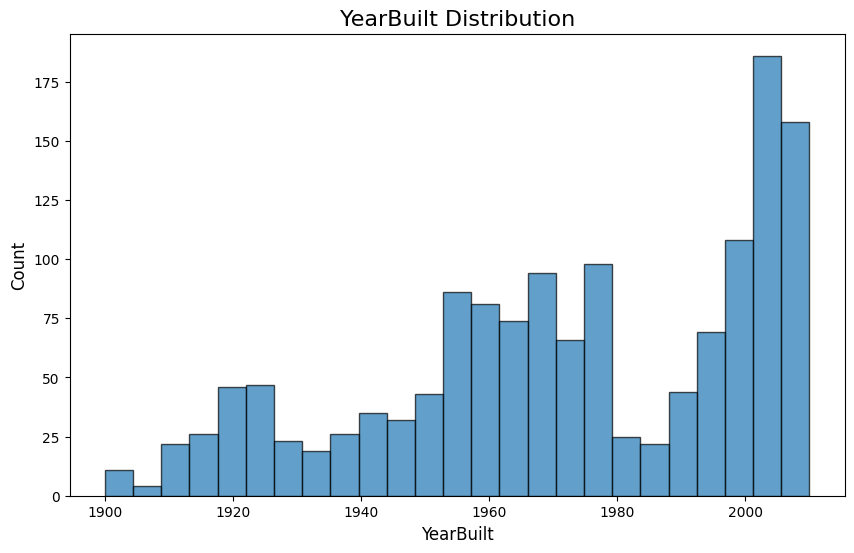

In [4]:
plt.figure(figsize=(10, 6))
plt.hist(years, bins=25, edgecolor="black", alpha=0.7)
plt.title("YearBuilt Distribution", fontsize=16)
plt.xlabel("YearBuilt", fontsize=12)
plt.ylabel("Count", fontsize=12)



In [6]:
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]


In [7]:
print(df["HouseAge"].describe())

count    1460.000000
mean       36.547945
std        30.250152
min         0.000000
25%         8.000000
50%        35.000000
75%        54.000000
max       136.000000
Name: HouseAge, dtype: float64


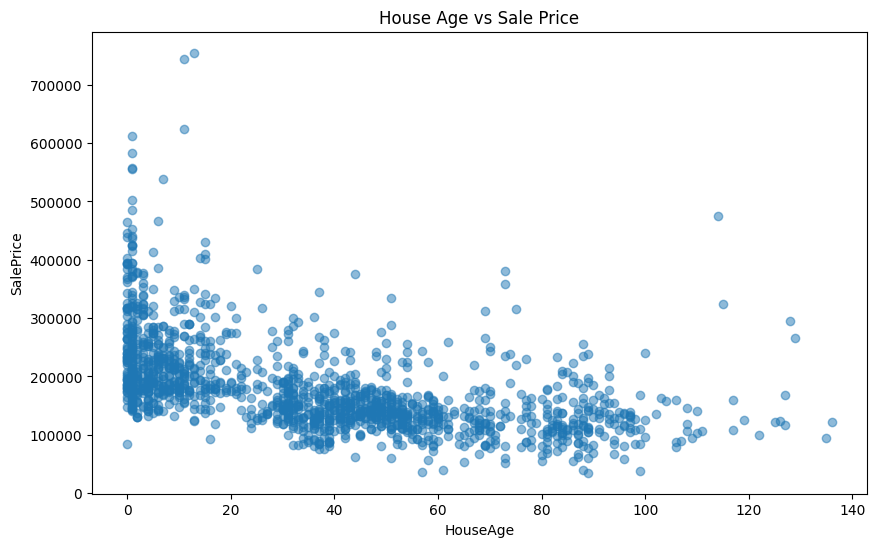

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df["HouseAge"], df["SalePrice"], alpha=0.5)
plt.title("House Age vs Sale Price")
plt.xlabel("HouseAge")
plt.ylabel("SalePrice")
plt.show()

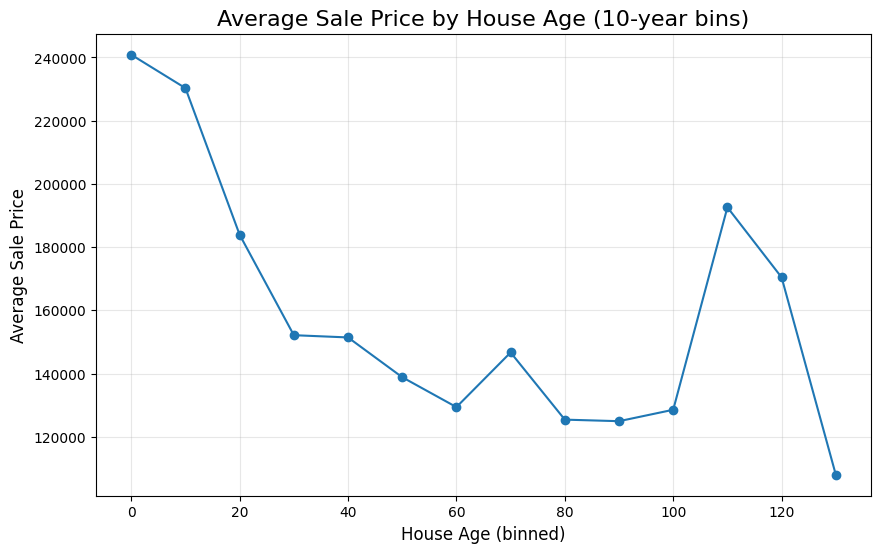

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv("train.csv")

# 创建 HouseAge 列
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

# 按 10 年分组
df["AgeBin"] = (df["HouseAge"] // 10) * 10

# 计算每组的平均售价
avg_price_by_age = df.groupby("AgeBin")["SalePrice"].mean().reset_index()

# 画趋势图
plt.figure(figsize=(10,6))
plt.plot(avg_price_by_age["AgeBin"], avg_price_by_age["SalePrice"], marker='o', linestyle='-')
plt.title("Average Sale Price by House Age (10-year bins)", fontsize=16)
plt.xlabel("House Age (binned)", fontsize=12)
plt.ylabel("Average Sale Price", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

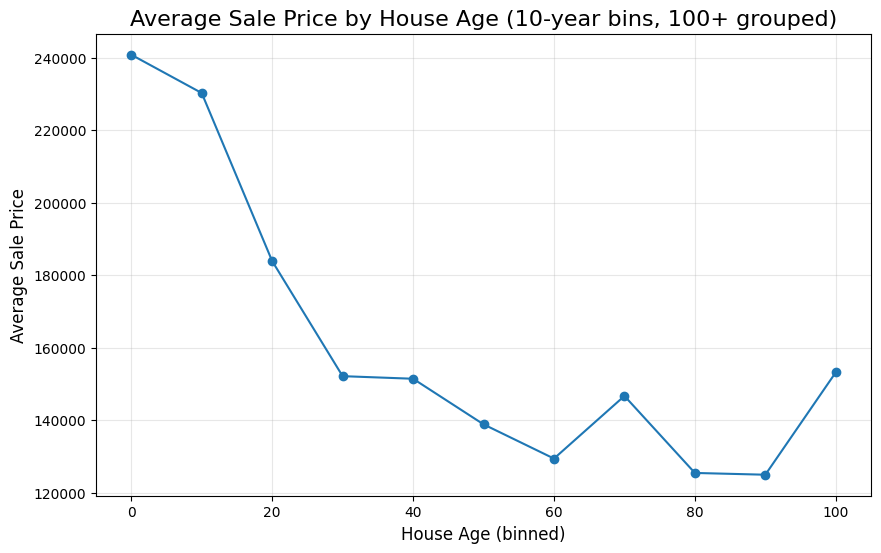

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 假设 df 已经有 HouseAge
df["AgeBin"] = (df["HouseAge"] // 10) * 10
df.loc[df["HouseAge"] >= 100, "AgeBin"] = 100  # 100+ 归为一类

# 计算均值
avg_price_by_age = df.groupby("AgeBin")["SalePrice"].mean().reset_index()

# 画图
plt.figure(figsize=(10,6))
plt.plot(avg_price_by_age["AgeBin"], avg_price_by_age["SalePrice"], marker='o', linestyle='-')
plt.title("Average Sale Price by House Age (10-year bins, 100+ grouped)", fontsize=16)
plt.xlabel("House Age (binned)", fontsize=12)
plt.ylabel("Average Sale Price", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

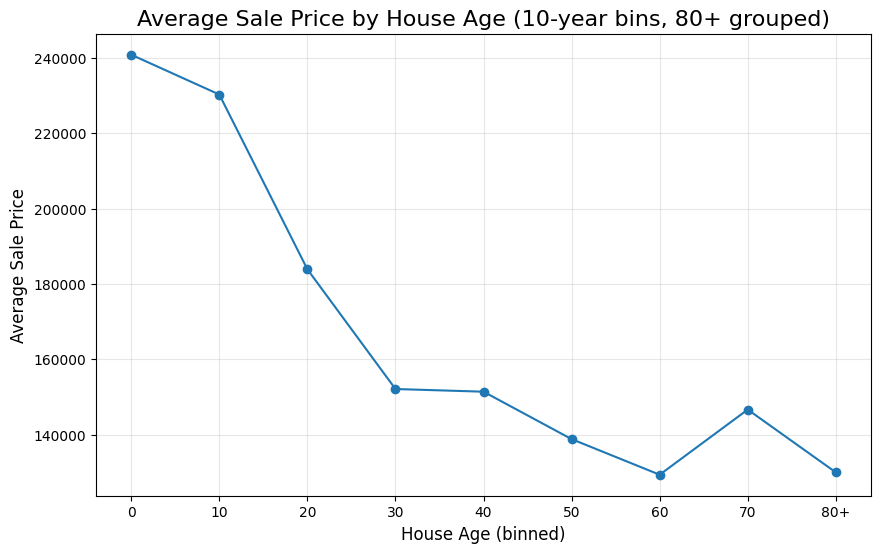

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 假设 df 已经有 HouseAge
df["AgeBin"] = (df["HouseAge"] // 10) * 10
df.loc[df["HouseAge"] >= 80, "AgeBin"] = 80  # 80+ 归为一类

# 计算平均售价
avg_price_by_age = df.groupby("AgeBin")["SalePrice"].mean().reset_index()

# 修改 AgeBin 的显示
avg_price_by_age["AgeBin"] = avg_price_by_age["AgeBin"].astype(str)
avg_price_by_age.loc[avg_price_by_age["AgeBin"] == "80", "AgeBin"] = "80+"

# 画图
plt.figure(figsize=(10,6))
plt.plot(avg_price_by_age["AgeBin"], avg_price_by_age["SalePrice"], marker='o', linestyle='-')
plt.title("Average Sale Price by House Age (10-year bins, 80+ grouped)", fontsize=16)
plt.xlabel("House Age (binned)", fontsize=12)
plt.ylabel("Average Sale Price", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

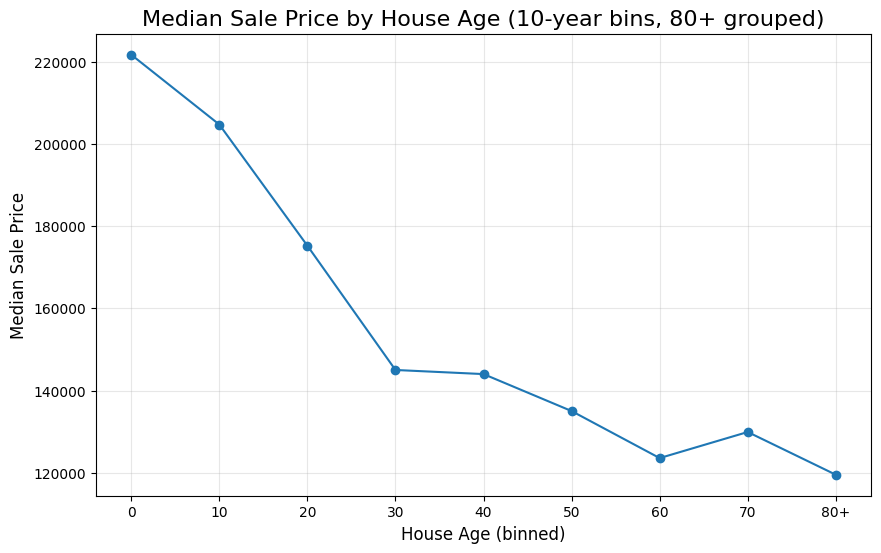

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 假设 df 已经有 HouseAge
df["AgeBin"] = (df["HouseAge"] // 10) * 10
df.loc[df["HouseAge"] >= 80, "AgeBin"] = 80  # 80+ 归为一类

# 计算中位数售价
median_price_by_age = df.groupby("AgeBin")["SalePrice"].median().reset_index()

# 修改 AgeBin 的显示
median_price_by_age["AgeBin"] = median_price_by_age["AgeBin"].astype(str)
median_price_by_age.loc[median_price_by_age["AgeBin"] == "80", "AgeBin"] = "80+"

# 画图
plt.figure(figsize=(10,6))
plt.plot(median_price_by_age["AgeBin"], median_price_by_age["SalePrice"], marker='o', linestyle='-')
plt.title("Median Sale Price by House Age (10-year bins, 80+ grouped)", fontsize=16)
plt.xlabel("House Age (binned)", fontsize=12)
plt.ylabel("Median Sale Price", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_28760\2889136780.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('AgePercentile')['SalePrice'].mean().reset_index()


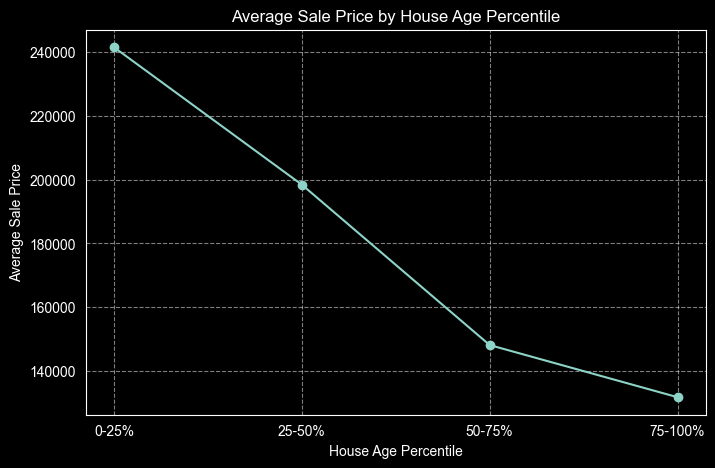

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读数据
df = pd.read_csv("train.csv")

# 计算房龄
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

# 按百分位切分
df['AgePercentile'] = pd.qcut(
    df['HouseAge'],
    q=4,
    labels=['0-25%', '25-50%', '50-75%', '75-100%']
)

# 按分位组计算平均售价
grouped = df.groupby('AgePercentile')['SalePrice'].mean().reset_index()

# 绘图
plt.style.use('dark_background')
plt.figure(figsize=(8,5))
plt.plot(grouped['AgePercentile'], grouped['SalePrice'],
         marker='o', linestyle='-')
plt.xlabel("House Age Percentile")
plt.ylabel("Average Sale Price")
plt.title("Average Sale Price by House Age Percentile")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
2. 房子的质量


===== OverallQual 描述统计 =====
count    1460.000000
mean        6.099315
std         1.382997
min         1.000000
5%          4.000000
25%         5.000000
50%         6.000000
75%         7.000000
95%         8.000000
max        10.000000
Name: OverallQual, dtype: float64


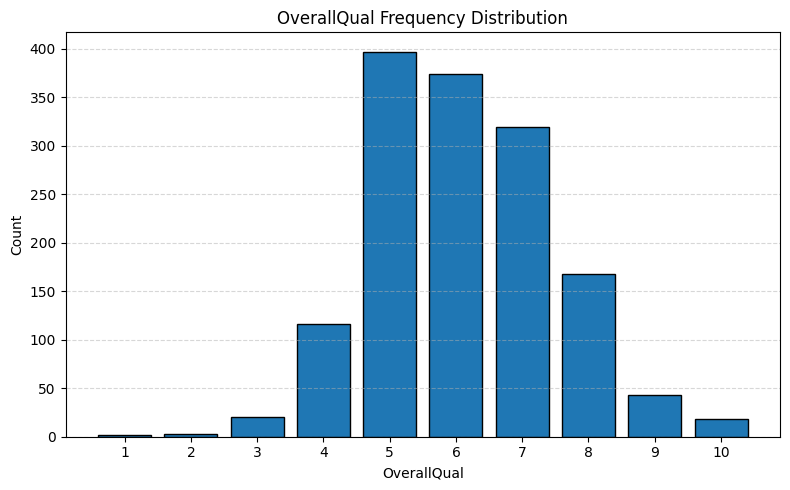

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) 读数据
FILE_PATH = "train.csv"   # 确认路径
df = pd.read_csv(FILE_PATH)

# 2) 提取并清洗 OverallQual
qual = pd.to_numeric(df["OverallQual"], errors="coerce").dropna().astype(int)

# 3) 描述统计
print("===== OverallQual 描述统计 =====")
print(qual.describe(percentiles=[.05, .25, .5, .75, .95]))

# 4) 频数分布条形图
counts = qual.value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(counts.index.astype(str), counts.values, edgecolor="black")
plt.title("OverallQual Frequency Distribution")
plt.xlabel("OverallQual")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

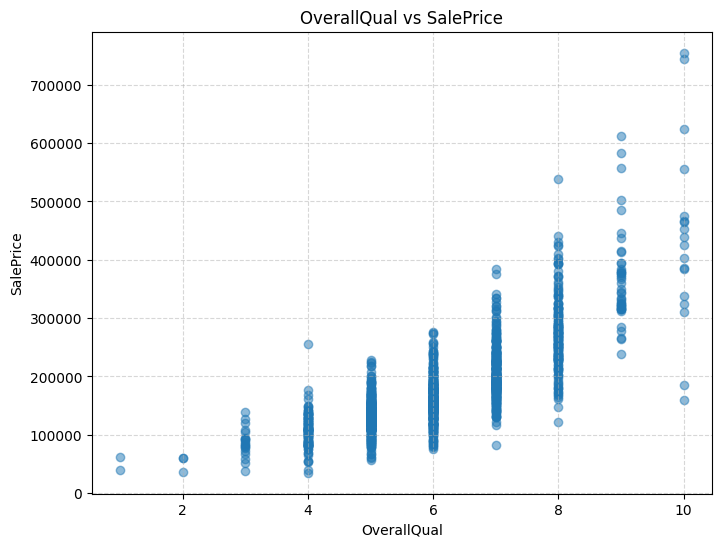

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(df["OverallQual"], df["SalePrice"], alpha=0.5)
plt.title("OverallQual vs SalePrice")
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [ ]:
3.

===== GrLivArea Descriptive Stats =====
count    1460.000000
mean     1515.463699
std       525.480383
min       334.000000
5%        848.000000
25%      1129.500000
50%      1464.000000
75%      1776.750000
95%      2466.100000
max      5642.000000
Name: GrLivArea, dtype: float64


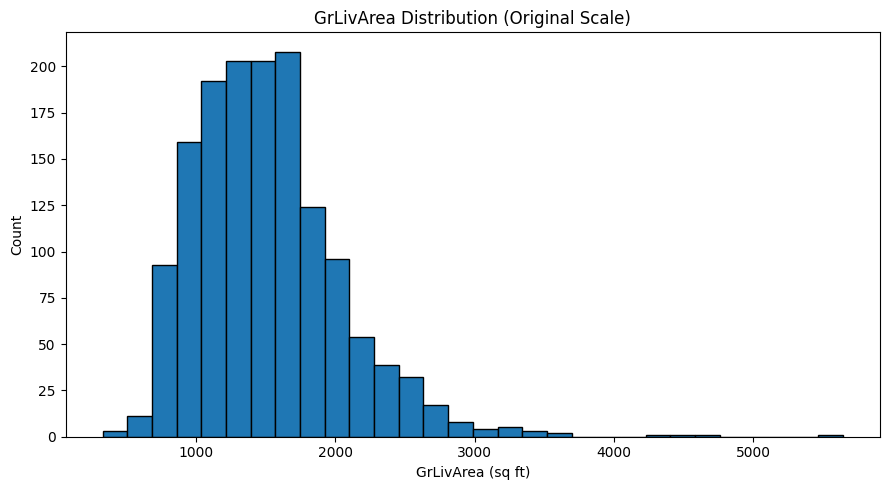


===== log1p(GrLivArea) Descriptive Stats =====
count    1460.000000
mean        7.268512
std         0.333303
min         5.814131
5%          6.744059
25%         7.030415
50%         7.289611
75%         7.483104
95%         7.810799
max         8.638171
Name: GrLivArea, dtype: float64


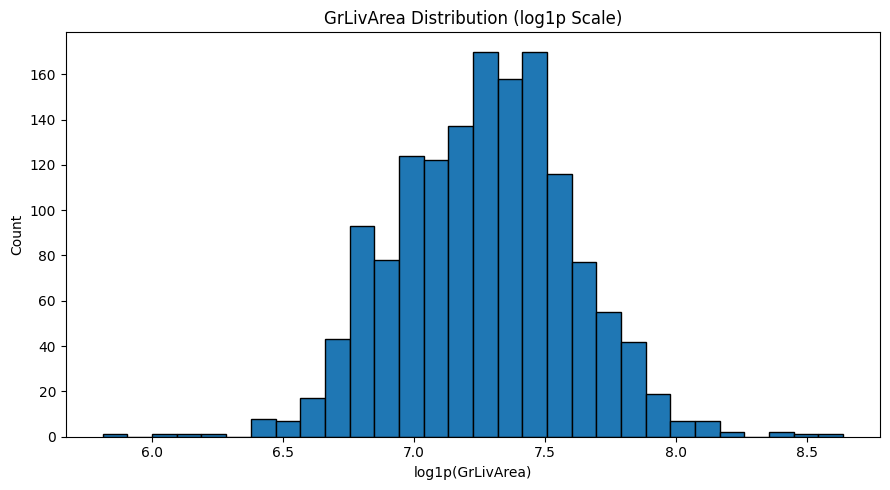

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Convert to numeric and drop invalid values
area = pd.to_numeric(df["GrLivArea"], errors="coerce").dropna()
area = area[area > 0]  # Remove non-positive values

# Descriptive statistics
print("===== GrLivArea Descriptive Stats =====")
print(area.describe(percentiles=[.05, .25, .5, .75, .95]))

# Histogram - original scale
plt.figure(figsize=(9,5))
plt.hist(area, bins=30, edgecolor="black")
plt.title("GrLivArea Distribution (Original Scale)")
plt.xlabel("GrLivArea (sq ft)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Histogram - log scale (to reduce skewness)
area_log = np.log1p(area)
print("\n===== log1p(GrLivArea) Descriptive Stats =====")
print(area_log.describe(percentiles=[.05, .25, .5, .75, .95]))

plt.figure(figsize=(9,5))
plt.hist(area_log, bins=30, edgecolor="black")
plt.title("GrLivArea Distribution (log1p Scale)")
plt.xlabel("log1p(GrLivArea)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [ ]:
1. 为什么要取对数（log1p）？

原始 GrLivArea 分布很右偏（大多数房子面积集中在中小户型，但少数豪宅面积特别大，会把分布拉得很长）。

如果直接用原始数据建模，可能导致回归残差不符合正态性、预测效果差。

取对数以后，可以让分布更接近 正态分布，对模型更友好。

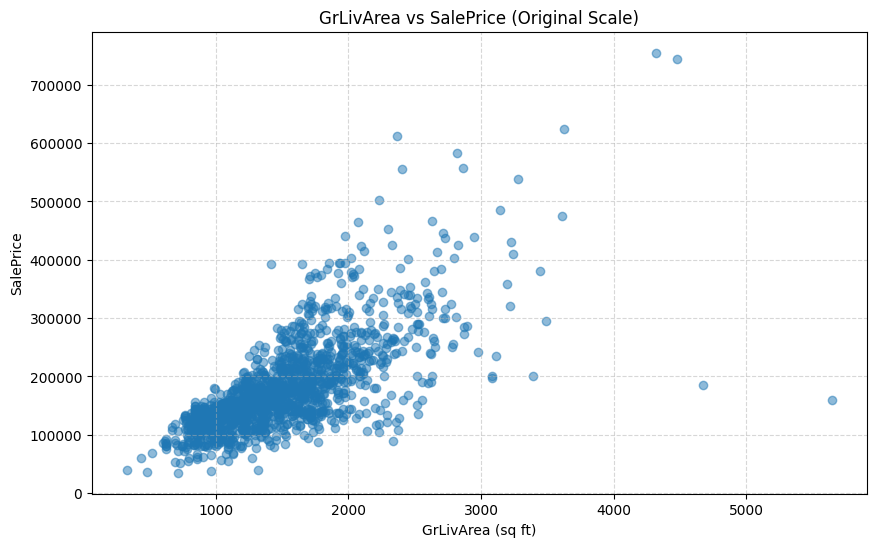

In [15]:
plt.figure(figsize=(10,6))
plt.scatter(df["GrLivArea"], df["SalePrice"], alpha=0.5)
plt.title("GrLivArea vs SalePrice (Original Scale)")
plt.xlabel("GrLivArea (sq ft)")
plt.ylabel("SalePrice")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_22680\3886023792.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = d.groupby('AreaBin').agg(


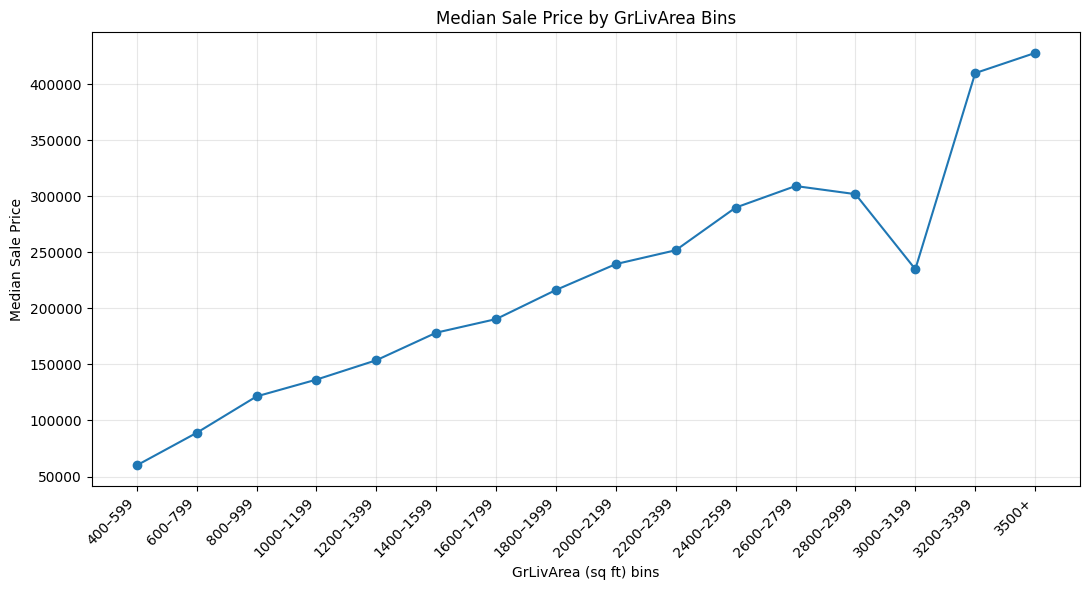

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

d = df[['GrLivArea','SalePrice']].dropna().copy()

# 自定义分箱：400 到 3400 每 200 一箱，最后一箱合并为 "3500+"
edges = list(range(400, 3600, 200)) + [10**9]
labels = [f'{edges[i]}–{edges[i+1]-1}' for i in range(len(edges)-2)] + ['3500+']
d['AreaBin'] = pd.cut(d['GrLivArea'], bins=edges, labels=labels, right=False)

# 每箱中位数 + 样本量
g = d.groupby('AreaBin').agg(
    median_price=('SalePrice','median'),
    mean_price=('SalePrice','mean'),
    n=('SalePrice','size')
).reset_index().dropna()

# 折线图（中位数）
plt.figure(figsize=(11,6))
plt.plot(g['AreaBin'].astype(str), g['median_price'], marker='o')
plt.xticks(rotation=45, ha='right')
plt.title('Median Sale Price by GrLivArea Bins')
plt.xlabel('GrLivArea (sq ft) bins')
plt.ylabel('Median Sale Price')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

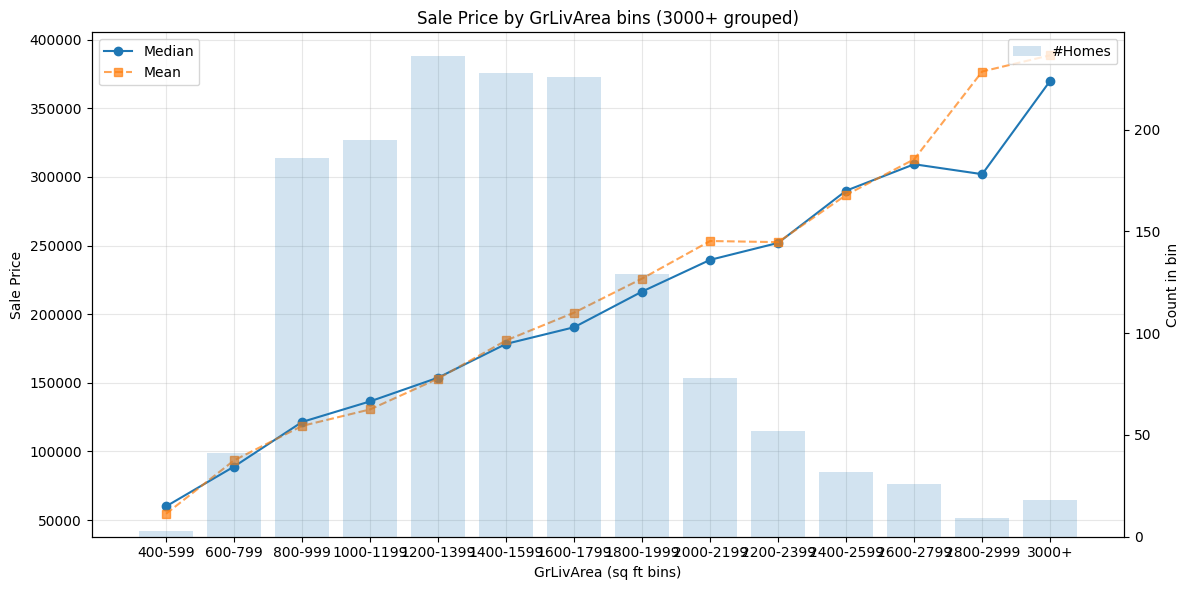

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 只取需要的列
d = df[['GrLivArea','SalePrice']].dropna().copy()

# 1) 设定边界：400 到 3000 之前每 200 一档，3000 为分界，再加一个最大上界
max_area = int(d['GrLivArea'].max())
bins = list(range(400, 3000, 200)) + [3000, max_area + 1]

# 2) 设定标签：与区间一一对应（数量 = len(bins) - 1）
labels = [f'{i}-{i+199}' for i in range(400, 3000, 200)] + ['3000+']

# 3) 自检（调试用）：数量必须匹配
assert len(labels) == len(bins) - 1, f'labels={len(labels)}, bins={len(bins)}'

# 4) 分箱
d['AreaBin'] = pd.cut(
    d['GrLivArea'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False,       # 区间左闭右开：[400,600)
    ordered=True
)

# 5) 统计（observed=True 避免把空箱也算进去）
g = (d.groupby('AreaBin', observed=True)
       .agg(median_price=('SalePrice','median'),
            mean_price=('SalePrice','mean'),
            n=('SalePrice','size'))
       .reset_index())

# 6) 画图：中位数&均值 + 右轴显示每箱样本数
fig, ax1 = plt.subplots(figsize=(12,6))
x = g['AreaBin'].astype(str)

ax1.plot(x, g['median_price'], marker='o', label='Median')
ax1.plot(x, g['mean_price'], marker='s', linestyle='--', alpha=0.7, label='Mean')
ax1.set_ylabel('Sale Price')
ax1.set_xlabel('GrLivArea (sq ft bins)')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.bar(x, g['n'], alpha=0.2, label='#Homes')
ax2.set_ylabel('Count in bin')
ax2.legend(loc='upper right')

plt.xticks(rotation=45, ha='right')
plt.title('Sale Price by GrLivArea bins (3000+ grouped)')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_28760\4048000282.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('AreaPercentile').agg(


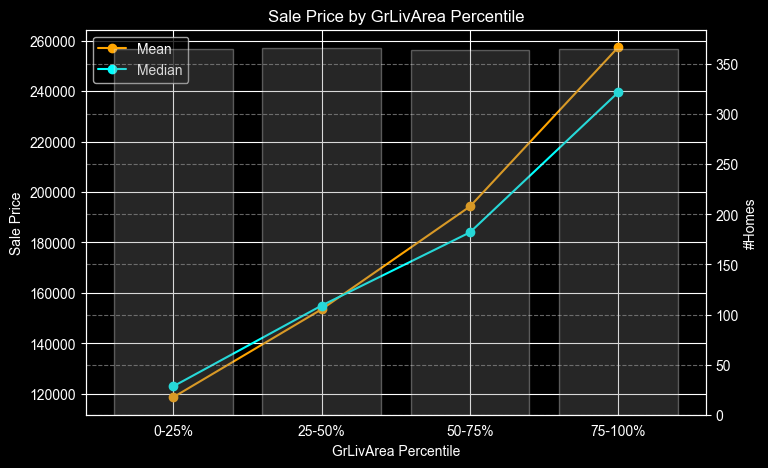

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读入数据
df = pd.read_csv("train.csv")

# 1. 计算分位数（0%、25%、50%、75%、100%）
percentiles = [0, 25, 50, 75, 100]
bins = np.percentile(df['GrLivArea'], percentiles)

# 2. 用 qcut 按百分位切分
df['AreaPercentile'] = pd.qcut(
    df['GrLivArea'],
    q=4,
    labels=['0-25%', '25-50%', '50-75%', '75-100%']
)

# 3. 按分位组计算平均价和中位价
grouped = df.groupby('AreaPercentile').agg(
    Mean=('SalePrice', 'mean'),
    Median=('SalePrice', 'median'),
    Homes=('SalePrice', 'count')
).reset_index()

# 4. 绘图
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(8,5))

# 画平均价和中位价曲线
ax1.plot(grouped['AreaPercentile'], grouped['Mean'], marker='o', linestyle='-', color='orange', label='Mean')
ax1.plot(grouped['AreaPercentile'], grouped['Median'], marker='o', linestyle='-', color='cyan', label='Median')
ax1.set_xlabel("GrLivArea Percentile")
ax1.set_ylabel("Sale Price")
ax1.legend(loc='upper left')

# 画房屋数量柱状图（用第二个y轴）
ax2 = ax1.twinx()
ax2.bar(grouped['AreaPercentile'], grouped['Homes'], color='gray', alpha=0.3, label='#Homes')
ax2.set_ylabel("#Homes")

plt.title("Sale Price by GrLivArea Percentile")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [ ]:
面积越大，房价一般越高；

但也会有一些 outliers（例如面积特别大但价格低的异常点）。

In [ ]:
4.

===== TotalBsmtSF Descriptive Stats =====
count    1460.000000
mean     1057.429452
std       438.705324
min         0.000000
5%        519.300000
25%       795.750000
50%       991.500000
75%      1298.250000
95%      1753.000000
max      6110.000000
Name: TotalBsmtSF, dtype: float64


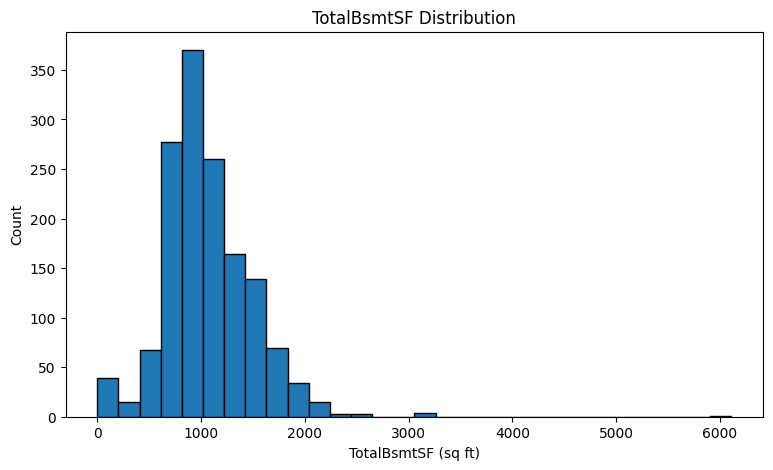

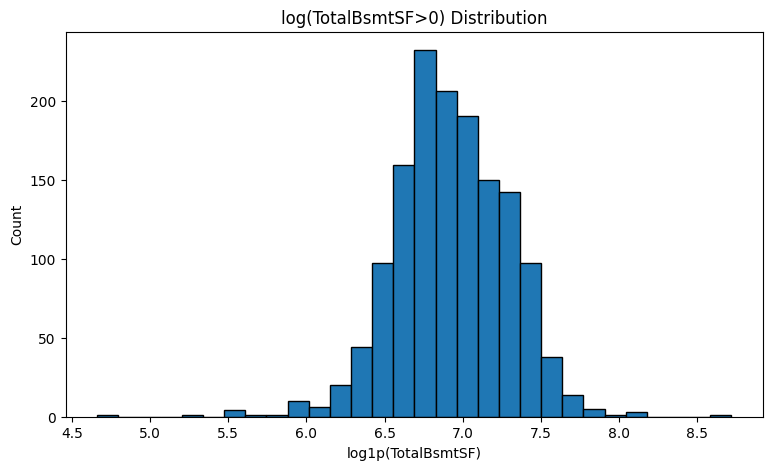

In [16]:
bsmt = pd.to_numeric(df["TotalBsmtSF"], errors="coerce").dropna()
bsmt = bsmt[bsmt >= 0]

print("===== TotalBsmtSF Descriptive Stats =====")
print(bsmt.describe(percentiles=[.05, .25, .5, .75, .95]))

plt.figure(figsize=(9,5))
plt.hist(bsmt, bins=30, edgecolor="black")
plt.title("TotalBsmtSF Distribution")
plt.xlabel("TotalBsmtSF (sq ft)")
plt.ylabel("Count")
plt.show()

# log scale for non-zero
bsmt_pos = bsmt[bsmt > 0]
plt.figure(figsize=(9,5))
plt.hist(np.log1p(bsmt_pos), bins=30, edgecolor="black")
plt.title("log(TotalBsmtSF>0) Distribution")
plt.xlabel("log1p(TotalBsmtSF)")
plt.ylabel("Count")
plt.show()

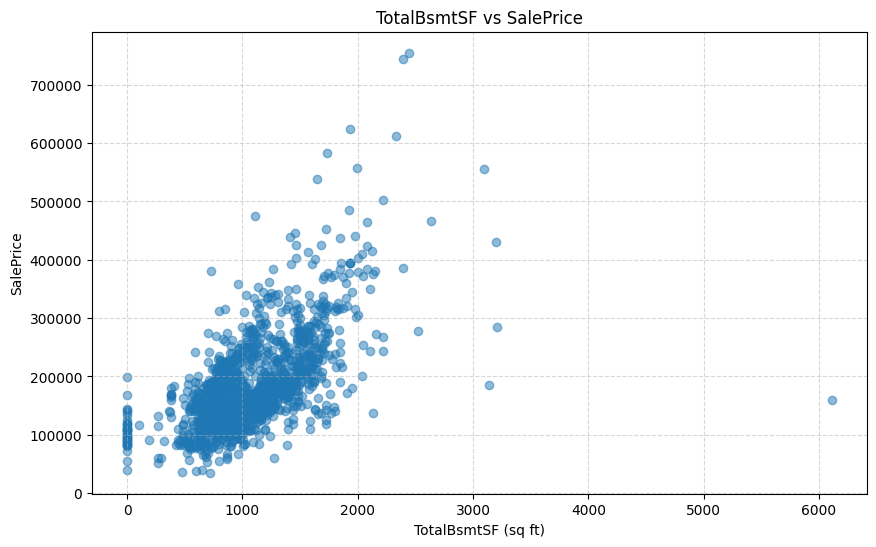

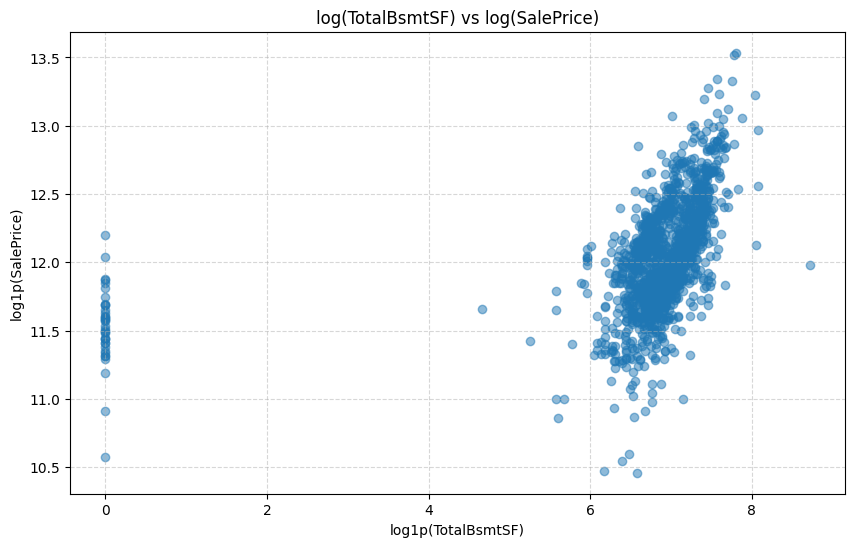

In [17]:
# Scatter
plt.figure(figsize=(10,6))
plt.scatter(df["TotalBsmtSF"], df["SalePrice"], alpha=0.5)
plt.title("TotalBsmtSF vs SalePrice")
plt.xlabel("TotalBsmtSF (sq ft)")
plt.ylabel("SalePrice")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# log-log Scatter
plt.figure(figsize=(10,6))
plt.scatter(np.log1p(df["TotalBsmtSF"]), np.log1p(df["SalePrice"]), alpha=0.5)
plt.title("log(TotalBsmtSF) vs log(SalePrice)")
plt.xlabel("log1p(TotalBsmtSF)")
plt.ylabel("log1p(SalePrice)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

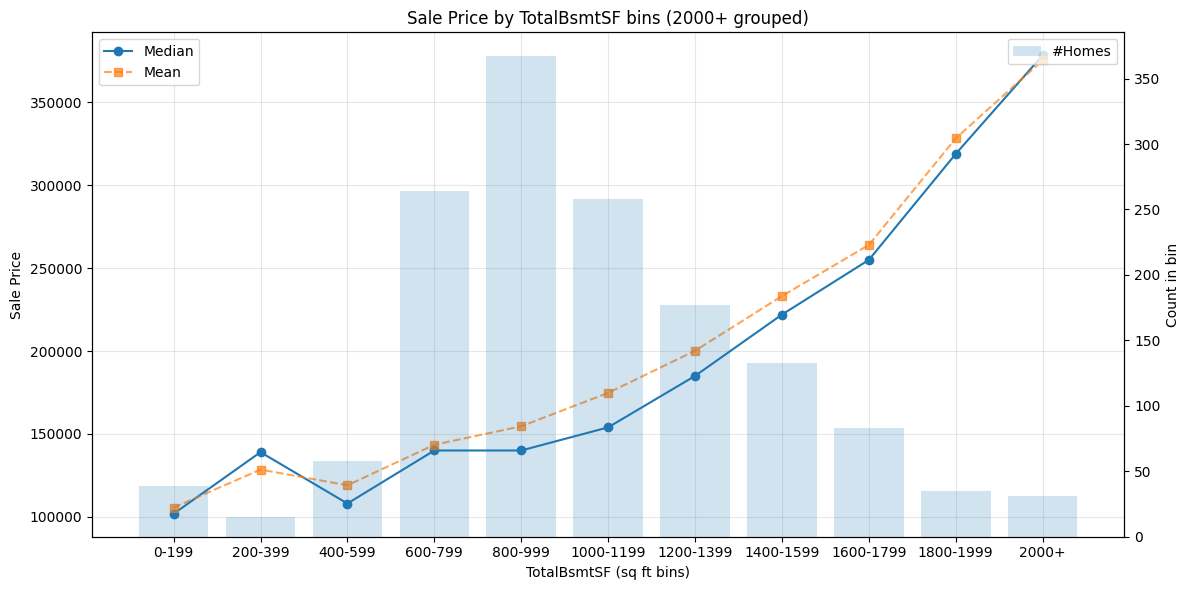

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

d = df[['TotalBsmtSF','SalePrice']].dropna().copy()

# 分箱边界：0 到 2000 每 200 一档，再加 2000+ 合在一起
max_x = int(d['TotalBsmtSF'].max())
bins = list(range(0, 2000, 200)) + [2000, max_x + 1]
labels = [f'{i}-{i+199}' for i in range(0, 2000, 200)] + ['2000+']

# 自检
assert len(labels) == len(bins) - 1

d['BsmtBin'] = pd.cut(d['TotalBsmtSF'], bins=bins, labels=labels, include_lowest=True, right=False, ordered=True)

g = (d.groupby('BsmtBin', observed=True)
       .agg(median_price=('SalePrice','median'),
            mean_price=('SalePrice','mean'),
            n=('SalePrice','size'))
       .reset_index())

# 画：中位数趋势 + 右轴显示样本数，便于评估稳定性
fig, ax1 = plt.subplots(figsize=(12,6))
x = g['BsmtBin'].astype(str)

ax1.plot(x, g['median_price'], marker='o', label='Median')
ax1.plot(x, g['mean_price'], marker='s', linestyle='--', alpha=0.7, label='Mean')
ax1.set_xlabel('TotalBsmtSF (sq ft bins)')
ax1.set_ylabel('Sale Price')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.bar(x, g['n'], alpha=0.2, label='#Homes')
ax2.set_ylabel('Count in bin')
ax2.legend(loc='upper right')

plt.xticks(rotation=45, ha='right')
plt.title('Sale Price by TotalBsmtSF bins (2000+ grouped)')
plt.tight_layout()
plt.show()

In [18]:
分布情况：

原始分布右偏，大部分房子地下室面积在 0–1500 平方英尺。

有相当一部分是 0（没有地下室），这是一个重要的特征差异点。

取对数后，正值分布更接近正态，更适合建模。

极端值：

存在一些超过 4000+ 平方英尺 的超大地下室，这些属于 outliers。

📈 与 SalePrice 的关系

正相关：

散点图显示，地下室面积越大，房价通常越高。

在对数尺度下（log-log 散点图），关系更接近线性。

0 值的影响：

没有地下室的房子（TotalBsmtSF=0）整体房价水平显著低于有地下室的房子。

说明“有没有地下室”本身就是一个强分类信号。


SyntaxError: invalid character '：' (U+FF1A) (474889015.py, line 1)

  BsmtPercentile      MeanPrice  MedianPrice  Homes
0          0-25%  134233.021918     131000.0    365
1         25-50%  154218.002740     140000.0    365
2         50-75%  179998.663014     159895.0    365
3        75-100%  255235.095890     235000.0    365


C:\Users\User\AppData\Local\Temp\ipykernel_28760\4115238938.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('BsmtPercentile').agg(


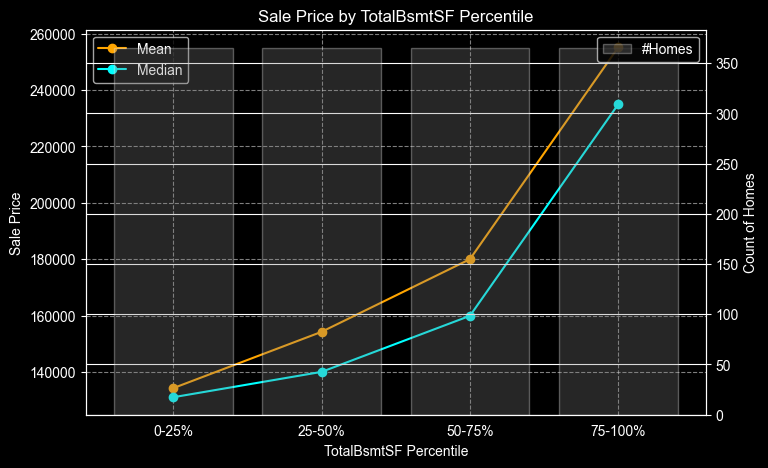

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 读入数据
df = pd.read_csv("train.csv")

# 2. 计算 TotalBsmtSF 的百分位切分
percentiles = [0, 25, 50, 75, 100]
df['BsmtPercentile'] = pd.qcut(
    df['TotalBsmtSF'],
    q=4,
    labels=['0-25%', '25-50%', '50-75%', '75-100%']
)

# 3. 按分位组计算平均价、中位价、样本数量
grouped = df.groupby('BsmtPercentile').agg(
    MeanPrice=('SalePrice', 'mean'),
    MedianPrice=('SalePrice', 'median'),
    Homes=('SalePrice', 'count')
).reset_index()

print(grouped)

# 4. 绘图
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(8,5))

# 左轴：价格曲线
ax1.plot(grouped['BsmtPercentile'], grouped['MeanPrice'],
         marker='o', linestyle='-', color='orange', label='Mean')
ax1.plot(grouped['BsmtPercentile'], grouped['MedianPrice'],
         marker='o', linestyle='-', color='cyan', label='Median')
ax1.set_xlabel("TotalBsmtSF Percentile")
ax1.set_ylabel("Sale Price")
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

# 右轴：样本数量柱状图
ax2 = ax1.twinx()
ax2.bar(grouped['BsmtPercentile'], grouped['Homes'],
        alpha=0.3, color='gray', label='#Homes')
ax2.set_ylabel("Count of Homes")
ax2.legend(loc='upper right')

plt.title("Sale Price by TotalBsmtSF Percentile")
plt.show()

In [ ]:
5.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_feature(df, feature, target="SalePrice", bins=None, log=False):
    series = pd.to_numeric(df[feature], errors="coerce").dropna()

    print(f"\n===== {feature} Descriptive Stats =====")
    print(series.describe(percentiles=[.05, .25, .5, .75, .95]))

    plt.figure(figsize=(8,5))
    if series.nunique() < 20:  # treat as categorical
        counts = series.value_counts().sort_index()
        plt.bar(counts.index.astype(str), counts.values, edgecolor="black")
        plt.title(f"{feature} Frequency Distribution")
        plt.xlabel(feature)
        plt.ylabel("Count")
    else:  # continuous
        plt.hist(series, bins=30, edgecolor="black")
        plt.title(f"{feature} Distribution")
        plt.xlabel(feature)
        plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # relationship with target
    if series.nunique() < 20:  # categorical boxplot
        plt.figure(figsize=(10,6))
        sns.boxplot(x=feature, y=target, data=df)
        plt.title(f"{target} by {feature}")
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.show()
    else:  # continuous scatter
        plt.figure(figsize=(10,6))
        plt.scatter(df[feature], df[target], alpha=0.5)
        plt.title(f"{feature} vs {target}")
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.show()

        if log:
            plt.figure(figsize=(10,6))
            plt.scatter(np.log1p(df[feature]), np.log1p(df[target]), alpha=0.5)
            plt.title(f"log({feature}) vs log({target})")
            plt.xlabel(f"log1p({feature})")
            plt.ylabel(f"log1p({target})")
            plt.grid(True, linestyle="--", alpha=0.5)
            plt.show()

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
Q1: 要不要我帮你写一个 不依赖 seaborn 的版本，只用 matplotlib 也能画出箱线图？

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analyze_feature(df, feature, target="SalePrice", log=False):
    series = pd.to_numeric(df[feature], errors="coerce").dropna()

    print(f"\n===== {feature} Descriptive Stats =====")
    print(series.describe(percentiles=[.05, .25, .5, .75, .95]))

    # --- Distribution plot ---
    plt.figure(figsize=(8,5))
    if series.nunique() < 20:  # categorical (discrete small values)
        counts = series.value_counts().sort_index()
        plt.bar(counts.index.astype(str), counts.values, edgecolor="black")
        plt.title(f"{feature} Frequency Distribution")
        plt.xlabel(feature)
        plt.ylabel("Count")
    else:  # continuous
        plt.hist(series, bins=30, edgecolor="black")
        plt.title(f"{feature} Distribution")
        plt.xlabel(feature)
        plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # --- Relationship with target ---
    if series.nunique() < 20:  # categorical → boxplot using matplotlib
        unique_vals = sorted(series.dropna().unique())
        data = [df[target][df[feature]==val].dropna() for val in unique_vals]

        plt.figure(figsize=(10,6))
        plt.boxplot(data, labels=[str(v) for v in unique_vals], patch_artist=True)
        plt.title(f"{target} by {feature}")
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.grid(axis="y", linestyle="--", alpha=0.5)
        plt.show()
    else:  # continuous → scatter
        plt.figure(figsize=(10,6))
        plt.scatter(df[feature], df[target], alpha=0.5)
        plt.title(f"{feature} vs {target}")
        plt.xlabel(feature)
        plt.ylabel(target)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.show()

        if log:
            plt.figure(figsize=(10,6))
            plt.scatter(np.log1p(df[feature]), np.log1p(df[target]), alpha=0.5)
            plt.title(f"log({feature}) vs log({target})")
            plt.xlabel(f"log1p({feature})")
            plt.ylabel(f"log1p({target})")
            plt.grid(True, linestyle="--", alpha=0.5)
            plt.show()


===== GarageCars Descriptive Stats =====
count    1460.000000
mean        1.767123
std         0.747315
min         0.000000
5%          0.000000
25%         1.000000
50%         2.000000
75%         2.000000
95%         3.000000
max         4.000000
Name: GarageCars, dtype: float64


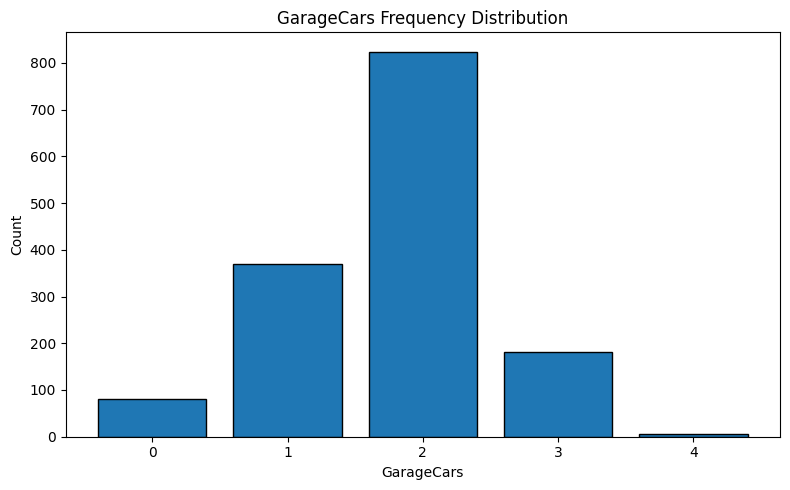

C:\Users\User\AppData\Local\Temp\ipykernel_12860\3831908680.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(v) for v in unique_vals], patch_artist=True)


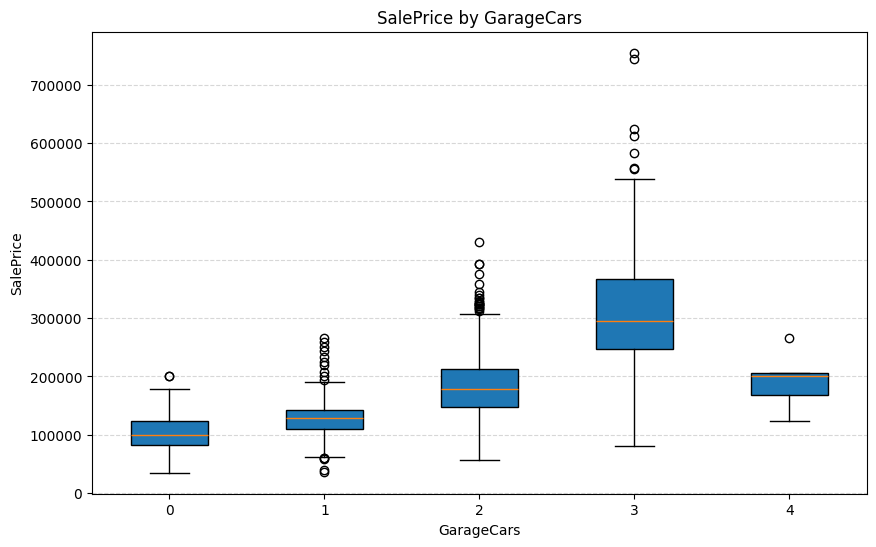

In [21]:
6.analyze_feature(df, "GarageCars")

C:\Users\User\AppData\Local\Temp\ipykernel_22680\2952293088.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='GarageBin', y='SalePrice', data=d, palette='Set2')


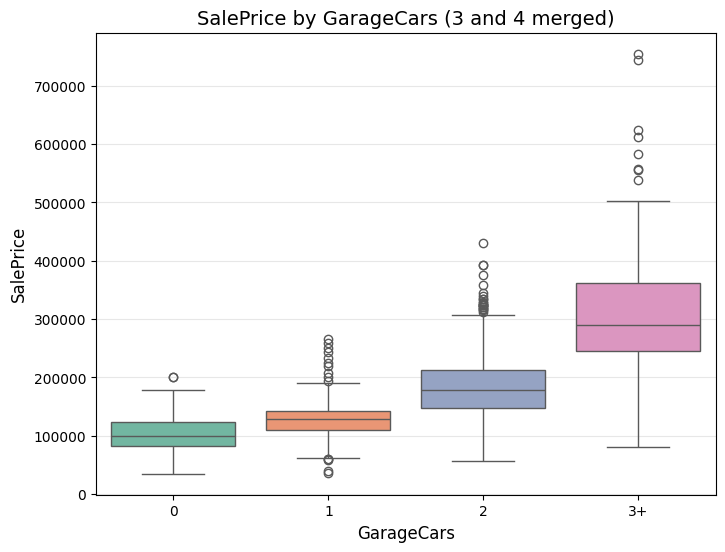

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

d = df[['GarageCars','SalePrice']].dropna().copy()

# 合并 3 和 4
d['GarageBin'] = d['GarageCars'].apply(lambda x: '3+' if x >= 3 else str(int(x)))

# 指定顺序
cat_type = pd.CategoricalDtype(categories=['0','1','2','3+'], ordered=True)
d['GarageBin'] = d['GarageBin'].astype(cat_type)

# 画箱线图
plt.figure(figsize=(8,6))
sns.boxplot(x='GarageBin', y='SalePrice', data=d, palette='Set2')

plt.title('SalePrice by GarageCars (3 and 4 merged)', fontsize=14)
plt.xlabel('GarageCars', fontsize=12)
plt.ylabel('SalePrice', fontsize=12)
plt.grid(True, axis='y', alpha=0.3)
plt.show()

In [ ]:
没有车库 (0)

中位数房价最低，大多数在 100,000 以下。

表明车库对房价确实有明显加成。

1 个车库

房价中位数比 0 高出一截（大约 120k 左右）。

分布比较集中，没有极端高价。

2 个车库

房价中位数进一步上升，大约在 170k–180k。

分布比较宽，说明两车库的房子价格差异大。

3 个车库

房价中位数最高（接近 300k），而且离群点显示有很多高价房。

表明大车库和高端住宅联系紧密。

4 个车库

样本很少，价格分布不稳定。

中位数比 3 低一些，但这个结论不稳固，主要受样本量小影响。

✅ 总结

GarageCars 和 SalePrice 呈现明显的正相关：车库数量越多，房价越高。

1 → 2 → 3 个车库 的价格提升最稳定，尤其从 2 到 3，房价增长幅度最大。

4 个车库 样本太少，结论不稳。

在建模时，可以既保留 GarageCars 的数值特征，也考虑加一个“是否 3+ 车库”的二元特征，用来捕捉高端住宅。


In [ ]:
7.


===== GarageArea Descriptive Stats =====
count    1460.000000
mean      472.980137
std       213.804841
min         0.000000
5%          0.000000
25%       334.500000
50%       480.000000
75%       576.000000
95%       850.100000
max      1418.000000
Name: GarageArea, dtype: float64


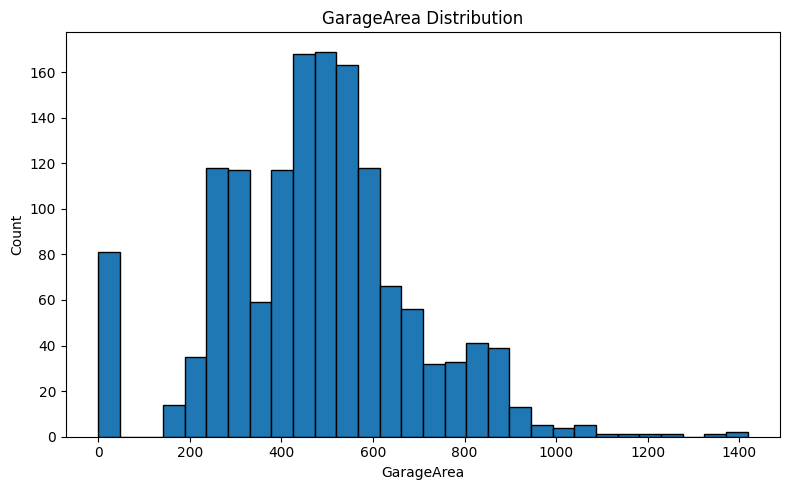

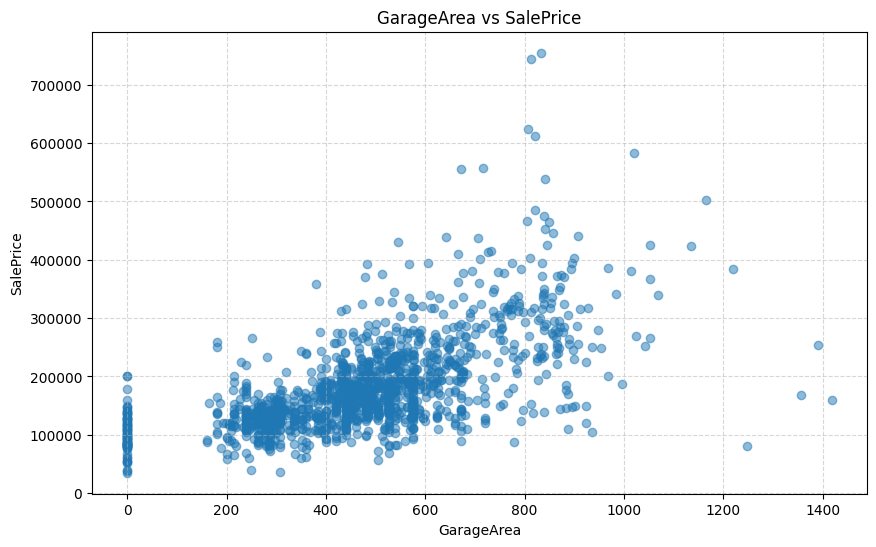

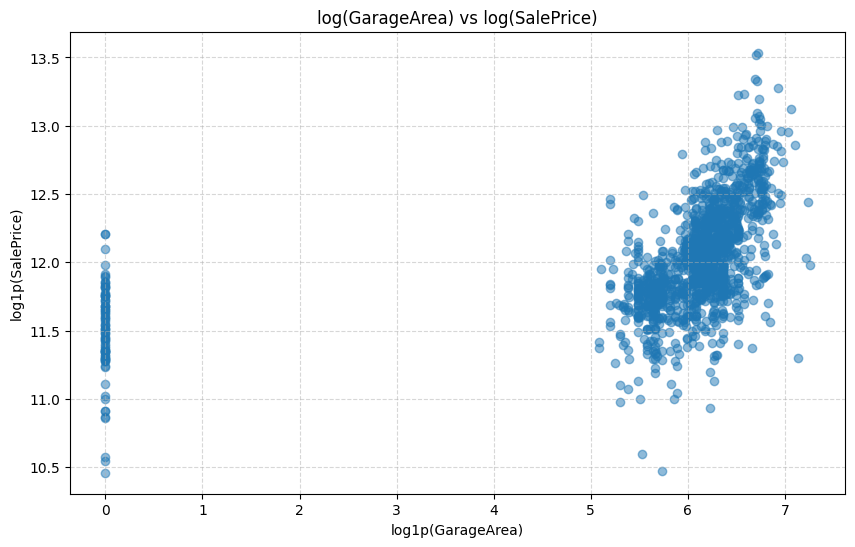

In [24]:
analyze_feature(df, "GarageArea", log=True)

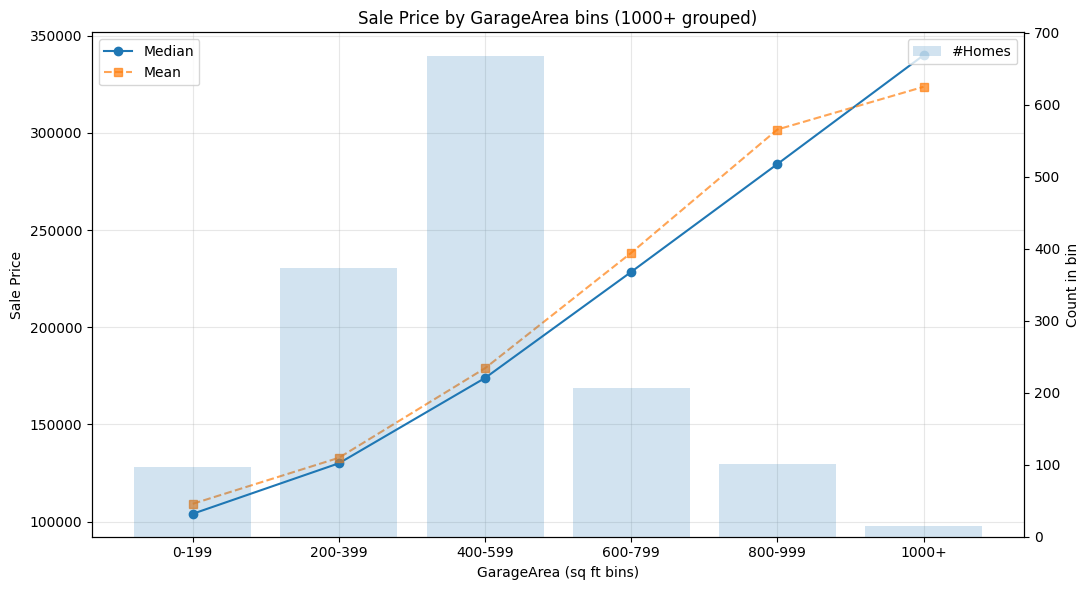

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 只取需要列
d = df[['GarageArea','SalePrice']].dropna().copy()

# —— 分箱：0~1000 每 200 一档，1000+ 合并 —— #
max_x = int(d['GarageArea'].max())
bins   = [0, 200, 400, 600, 800, 1000, max_x + 1]              # 7 个边界
labels = ['0-199','200-399','400-599','600-799','800-999','1000+']  # 6 个标签 (= 7-1)

# 自检（避免再次报错）
assert len(labels) == len(bins) - 1, (len(labels), len(bins))

d['GarageAreaBin'] = pd.cut(
    d['GarageArea'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False,      # [left, right)
    ordered=True
)

# 每箱统计：中位数/均值/样本数
g = (d.groupby('GarageAreaBin', observed=True)
       .agg(median_price=('SalePrice','median'),
            mean_price=('SalePrice','mean'),
            n=('SalePrice','size'))
       .reset_index())

# 画图：中位数趋势 + 右轴显示样本数，便于判断稳定性
fig, ax1 = plt.subplots(figsize=(11,6))
x = g['GarageAreaBin'].astype(str)

ax1.plot(x, g['median_price'], marker='o', label='Median')
ax1.plot(x, g['mean_price'], linestyle='--', marker='s', alpha=0.7, label='Mean')
ax1.set_xlabel('GarageArea (sq ft bins)')
ax1.set_ylabel('Sale Price')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.bar(x, g['n'], alpha=0.2, label='#Homes')
ax2.set_ylabel('Count in bin')
ax2.legend(loc='upper right')

plt.xticks(rotation=45, ha='right')
plt.title('Sale Price by GarageArea bins (1000+ grouped)')
plt.tight_layout()
plt.show()

In [ ]:
分布情况：

GarageArea 的分布偏右，大部分房子车库面积在 200–700 平方英尺（大概 1–2 个车位）。

有明显的 0 值（没有车库），这是一个特殊分组。

也有一些极端值（超过 1000+ 平方英尺），属于少数大车库。

对数变换效果：

在 log1p 后，正值部分分布更接近正态。

0 值单独成堆，和有车库的房子区别很大。

📈 与 SalePrice 的关系

原始散点图

总体趋势：车库面积越大，房价越高。

分布呈上升趋势，但有一些 outliers，比如车库很大但价格不高。

对数-对数散点图

在 log 尺度下，GarageArea 与 SalePrice 关系更接近 线性。

0 值的房子依旧单独成簇，说明“有没有车库”是一个关键特征。

相关性

GarageArea 和 SalePrice 呈现 中等到强的正相关。

与 GarageCars 一样，它同时反映了 数量（车位数）+ 质量（面积大小）。

✅ 总结

GarageArea 是房价的重要特征，和车位数量 (GarageCars) 相辅相成：

GarageCars 表示“能停几辆车”；

GarageArea 表示“实际空间大小”。

没有车库的房子整体房价明显偏低。


===== FullBath Descriptive Stats =====
count    1460.000000
mean        1.565068
std         0.550916
min         0.000000
5%          1.000000
25%         1.000000
50%         2.000000
75%         2.000000
95%         2.000000
max         3.000000
Name: FullBath, dtype: float64


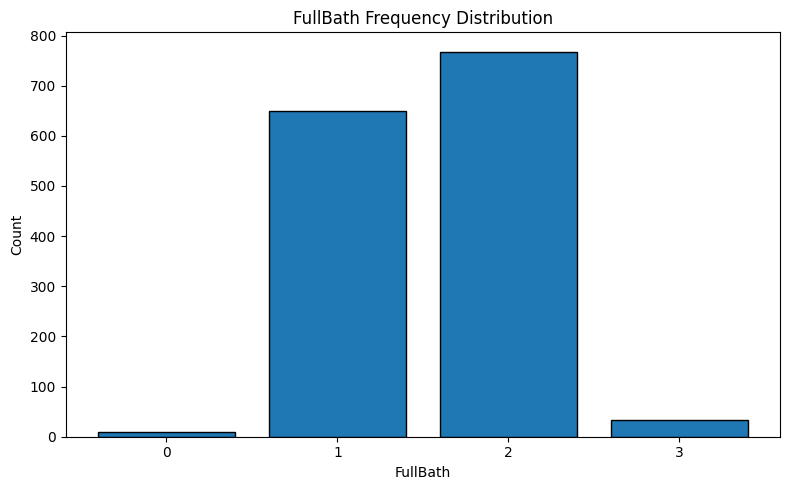

C:\Users\User\AppData\Local\Temp\ipykernel_12860\3831908680.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(v) for v in unique_vals], patch_artist=True)


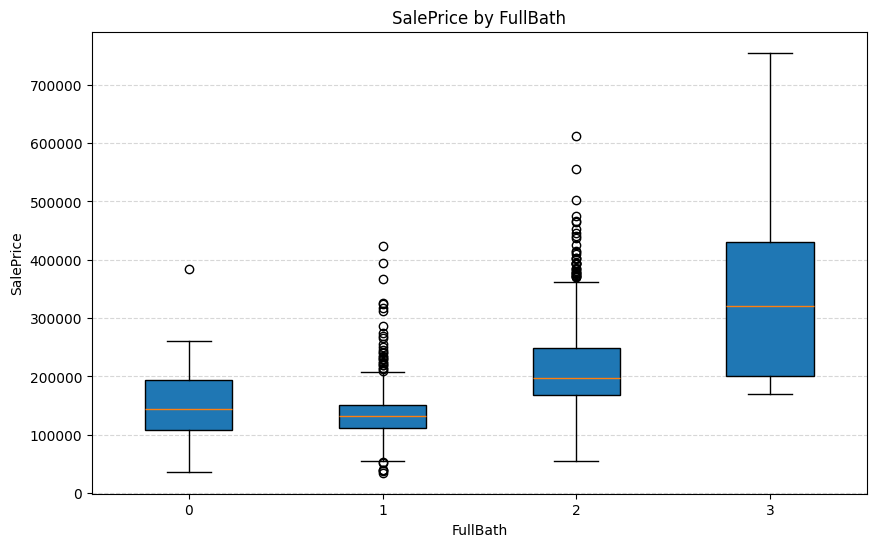

In [25]:
analyze_feature(df, "FullBath")

In [ ]:
数据特性

取值范围：0–3。

分布：

主要集中在 1 个全卫（约 650 套房）和 2 个全卫（约 750 套房），占绝大多数。

很少有 0 个全卫 或 3 个全卫 的房子。

统计特征：

中位数是 2 个全卫；

大部分房子至少有 1 个全卫。

📈 与 SalePrice 的关系

0 个全卫

样本极少，价格分布偏低。

有一些异常值（可能是数据标记问题，比如半卫被算成全卫=0）。

1 个全卫

中位数房价较低，大约在 120k–140k。

分布比较集中，几乎没有高价房。

2 个全卫

中位数明显上升，接近 200k。

价格分布更宽，能覆盖中等价位房。

3 个全卫

中位数房价最高（约 300k+），上限甚至超过 700k。

明显是高端住宅的标志。

✅ 总结

FullBath 与房价正相关：全卫越多，房价整体越高。

在 1 → 2 → 3 的变化中，房价的中位数和上限都逐级上升。

2 个全卫 是主流配置，3 个全卫 明显对应高端住宅。

建模时，FullBath 可以作为重要的分类/数值特征；同时，可以考虑与 HalfBath、BsmtFullBath 组合成 TotalBaths，可能更能反映整体卫生间数量对房价的影响。

In [ ]:
FullBath + HalfBath + BsmtFullBath + BsmtHalfBath 合并成一个更合理的指标：TotalBaths

===== TotalBaths Descriptive Stats =====
count    1460.000000
mean        2.210616
std         0.785399
min         1.000000
5%          1.000000
25%         2.000000
50%         2.000000
75%         2.500000
95%         3.500000
max         6.000000
Name: TotalBaths, dtype: float64


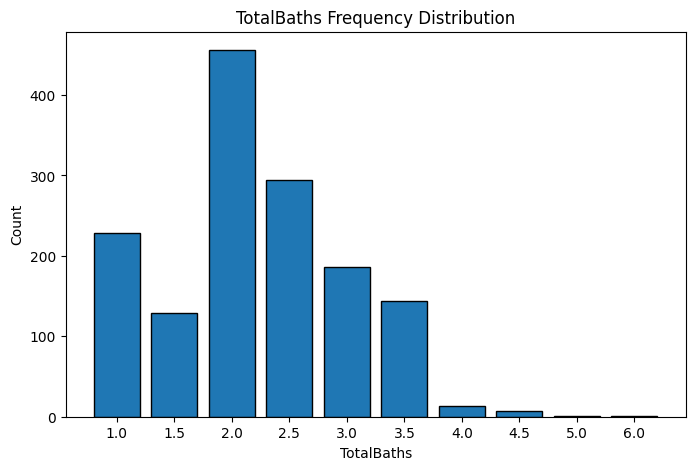

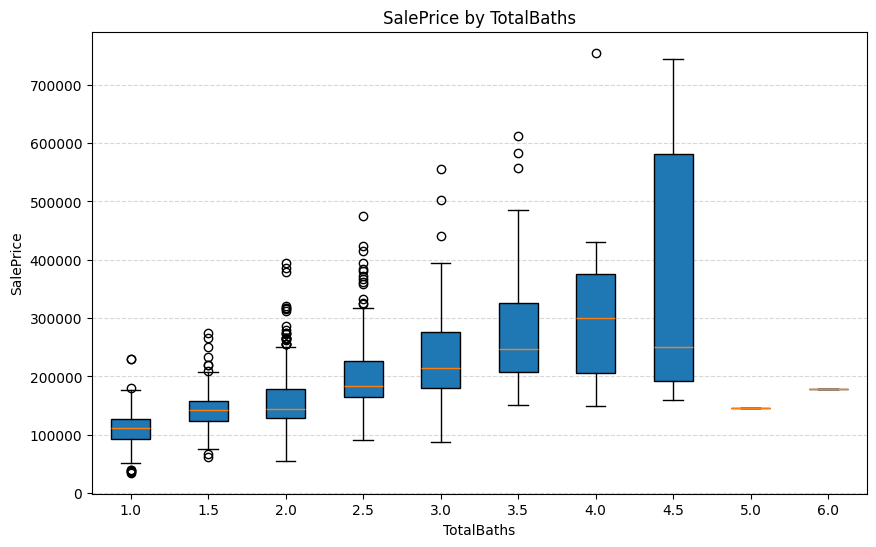

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# Create TotalBaths feature
df["TotalBaths"] = (
    df["FullBath"].fillna(0)
    + 0.5 * df["HalfBath"].fillna(0)
    + df["BsmtFullBath"].fillna(0)
    + 0.5 * df["BsmtHalfBath"].fillna(0)
)

# Descriptive stats
print("===== TotalBaths Descriptive Stats =====")
print(df["TotalBaths"].describe(percentiles=[.05, .25, .5, .75, .95]))

# Frequency distribution
counts = df["TotalBaths"].value_counts().sort_index()
plt.figure(figsize=(8,5))
plt.bar(counts.index.astype(str), counts.values, edgecolor="black")
plt.title("TotalBaths Frequency Distribution")
plt.xlabel("TotalBaths")
plt.ylabel("Count")
plt.show()

# Boxplot vs SalePrice
unique_vals = sorted(df["TotalBaths"].unique())
data = [df.loc[df["TotalBaths"]==val, "SalePrice"].dropna() for val in unique_vals]

plt.figure(figsize=(10,6))
plt.boxplot(data, tick_labels=[str(v) for v in unique_vals], patch_artist=True)
plt.title("SalePrice by TotalBaths")
plt.xlabel("TotalBaths")
plt.ylabel("SalePrice")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [ ]:
描述统计：你能看到总卫生间数量的分布范围。

频数直方图：显示大部分房子有 2–3 个卫生间。

箱线图：可以直观地看到 TotalBaths 越多，房价整体越高。


===== LotArea Descriptive Stats =====
count      1460.000000
mean      10516.828082
std        9981.264932
min        1300.000000
5%         3311.700000
25%        7553.500000
50%        9478.500000
75%       11601.500000
95%       17401.150000
max      215245.000000
Name: LotArea, dtype: float64


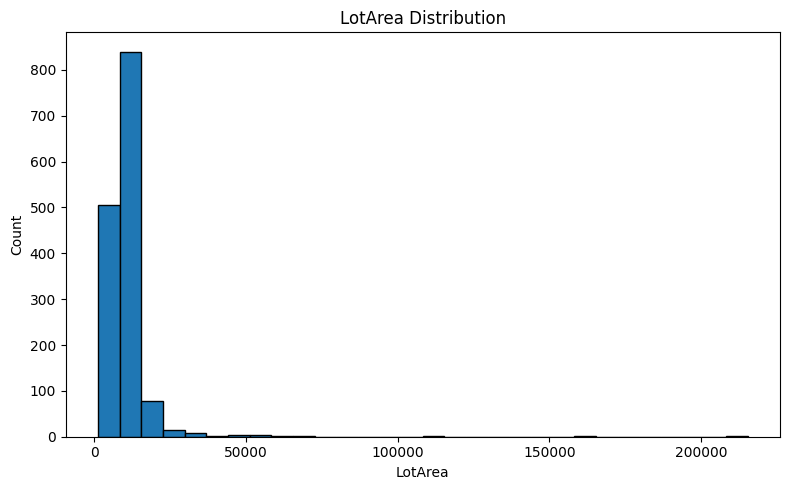

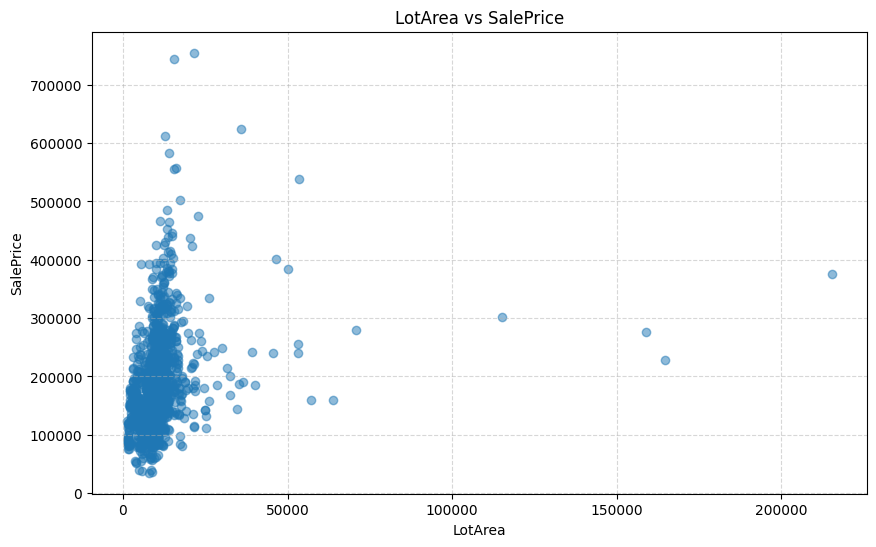

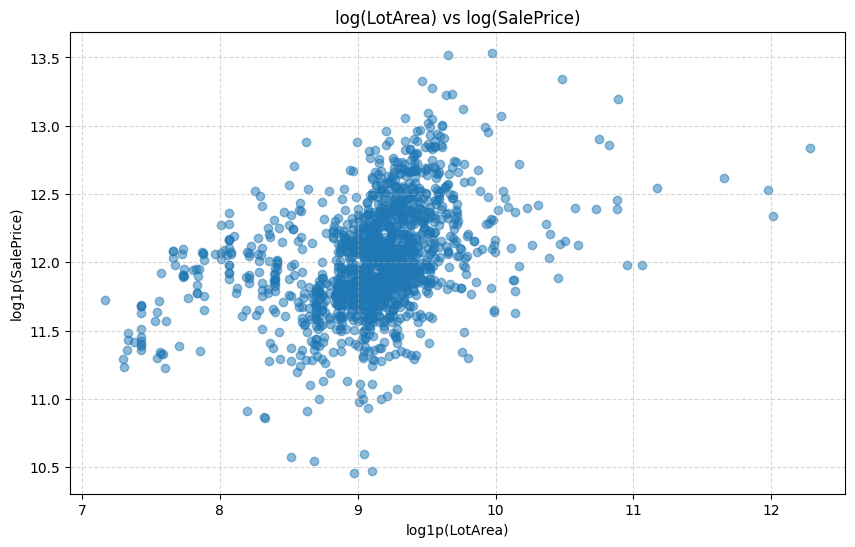

In [26]:
analyze_feature(df, "LotArea", log=True)

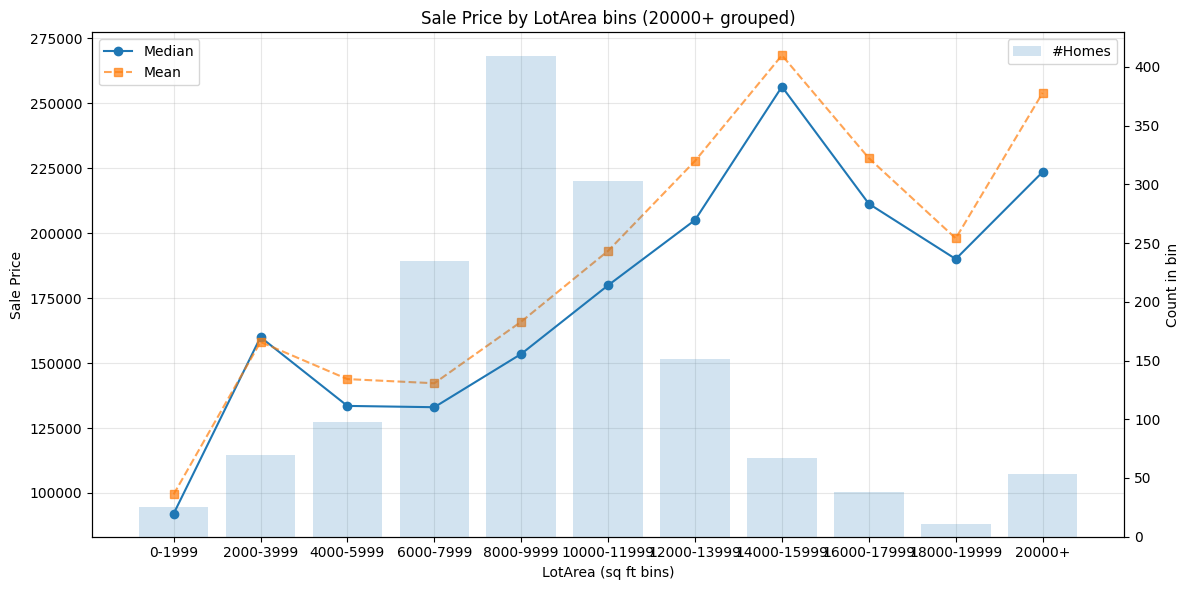

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

d = df[['LotArea','SalePrice']].dropna().copy()

# 分箱边界：0~20000 每 2000 一档，最后一档合并为 20000+
max_x = int(d['LotArea'].max())
bins   = list(range(0, 20000, 2000)) + [20000, max_x + 1]     # 边界
labels = [f'{i}-{i+1999}' for i in range(0, 20000, 2000)] + ['20000+']  # 标签

assert len(labels) == len(bins) - 1  # 自检，防止数量不匹配

d['LotAreaBin'] = pd.cut(
    d['LotArea'], bins=bins, labels=labels,
    include_lowest=True, right=False, ordered=True
)

# 每档统计
g = (d.groupby('LotAreaBin', observed=True)
       .agg(median_price=('SalePrice','median'),
            mean_price=('SalePrice','mean'),
            n=('SalePrice','size'))
       .reset_index())

# 画：中位数/均值 + 右轴样本数
fig, ax1 = plt.subplots(figsize=(12,6))
x = g['LotAreaBin'].astype(str)

ax1.plot(x, g['median_price'], marker='o', label='Median')
ax1.plot(x, g['mean_price'], marker='s', linestyle='--', alpha=0.7, label='Mean')
ax1.set_xlabel('LotArea (sq ft bins)')
ax1.set_ylabel('Sale Price')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.bar(x, g['n'], alpha=0.2, label='#Homes')
ax2.set_ylabel('Count in bin')
ax2.legend(loc='upper right')

plt.xticks(rotation=45, ha='right')
plt.title('Sale Price by LotArea bins (20000+ grouped)')
plt.tight_layout()
plt.show()

  LotAreaPercentile      MeanPrice  MedianPrice  Homes
0             0-25%  141115.260274     133000.0    365
1            25-50%  160787.687671     149900.0    365
2            50-75%  186030.183562     170000.0    365
3           75-100%  235751.652055     215000.0    365


C:\Users\User\AppData\Local\Temp\ipykernel_28760\1157270936.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('LotAreaPercentile').agg(


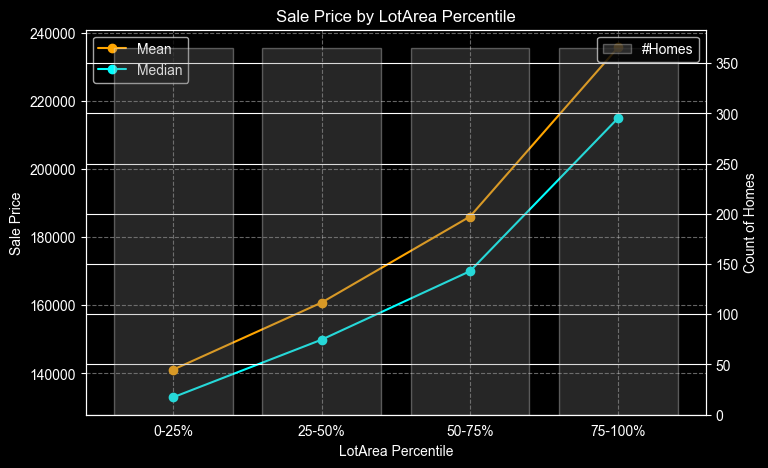

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 读入数据
df = pd.read_csv("train.csv")

# 2. 计算 LotArea 的分位区间
percentiles = [0, 25, 50, 75, 100]
df['LotAreaPercentile'] = pd.qcut(
    df['LotArea'],
    q=4,
    labels=['0-25%', '25-50%', '50-75%', '75-100%']
)

# 3. 按分位区间统计均值、中位数、样本数量
grouped = df.groupby('LotAreaPercentile').agg(
    MeanPrice=('SalePrice', 'mean'),
    MedianPrice=('SalePrice', 'median'),
    Homes=('SalePrice', 'count')
).reset_index()

print(grouped)

# 4. 绘图
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(8,5))

# 左轴：均值、中位数折线
ax1.plot(grouped['LotAreaPercentile'], grouped['MeanPrice'],
         marker='o', linestyle='-', color='orange', label='Mean')
ax1.plot(grouped['LotAreaPercentile'], grouped['MedianPrice'],
         marker='o', linestyle='-', color='cyan', label='Median')
ax1.set_xlabel("LotArea Percentile")
ax1.set_ylabel("Sale Price")
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.4)

# 右轴：样本数量柱状图
ax2 = ax1.twinx()
ax2.bar(grouped['LotAreaPercentile'], grouped['Homes'],
        alpha=0.3, color='gray', label='#Homes')
ax2.set_ylabel("Count of Homes")
ax2.legend(loc='upper right')

plt.title("Sale Price by LotArea Percentile")
plt.show()

In [ ]:
数据特性

分布情况

大多数房子的 LotArea 在 3000–15,000 平方英尺，中位数约 9500。

分布高度偏斜（右偏），存在极端大地块（>100,000，最大 215,245）。

平均值（约 10,500）被少数大地块拉高。

统计特征

75% 的房子 LotArea ≤ 11,600，说明超过一万的地块已经属于偏大户型。

95% 的房子 LotArea ≤ 17,400，极端大地块非常少。

📈 与 SalePrice 的关系

原始散点图

总体上，LotArea 越大房价可能越高，但关系并不强。

有很多异常点：一些非常大的地块价格并不高，说明“地块大 ≠ 一定高价”。

对数–对数散点图

在 log1p 尺度下，LotArea 与 SalePrice 的关系更接近线性。

显示出正相关趋势，但仍然比 GrLivArea、OverallQual 这些变量的相关性弱。

✅ 总结

LotArea 对房价有一定影响，但不是决定性因素。

它更多反映了房子的“地理位置 + 占地规模”。

大地块不一定对应高价，可能与地段、房屋质量、配套等因素相关。

建模时，LotArea 建议：

使用 log 变换（减少极端值影响）。

可以和 Neighborhood 联合使用，因为“地块面积 + 地段”组合可能更有解释力。

注意极端 outliers（>50,000 的少数点），在建模前可考虑单独处理。

In [ ]:
8.

===== YearRemodAdd Descriptive Stats =====
count    1460.000000
mean     1984.865753
std        20.645407
min      1950.000000
5%       1950.000000
25%      1967.000000
50%      1994.000000
75%      2004.000000
95%      2007.000000
max      2010.000000
Name: YearRemodAdd, dtype: float64


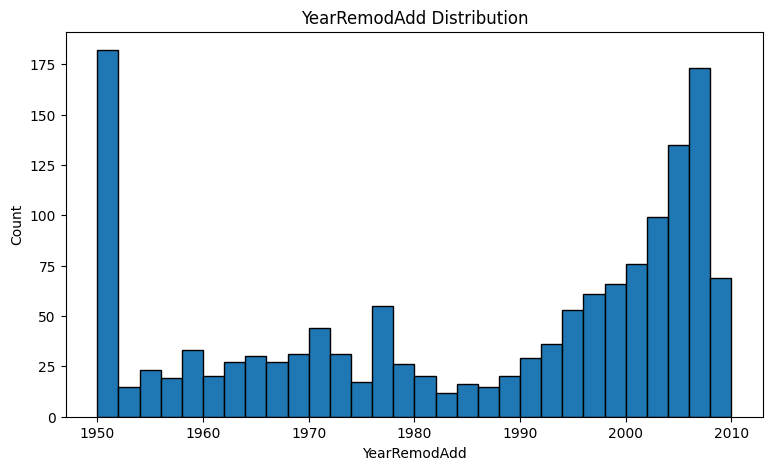

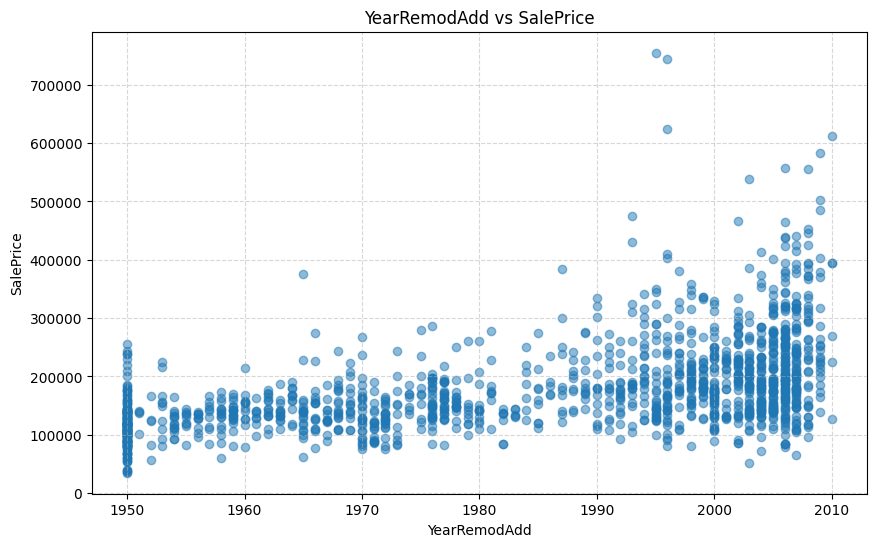

In [30]:
# Descriptive stats
remod = pd.to_numeric(df["YearRemodAdd"], errors="coerce").dropna()
print("===== YearRemodAdd Descriptive Stats =====")
print(remod.describe(percentiles=[.05, .25, .5, .75, .95]))

# Histogram
plt.figure(figsize=(9,5))
plt.hist(remod, bins=30, edgecolor="black")
plt.title("YearRemodAdd Distribution")
plt.xlabel("YearRemodAdd")
plt.ylabel("Count")
plt.show()

# Scatter vs SalePrice
plt.figure(figsize=(10,6))
plt.scatter(df["YearRemodAdd"], df["SalePrice"], alpha=0.5)
plt.title("YearRemodAdd vs SalePrice")
plt.xlabel("YearRemodAdd")
plt.ylabel("SalePrice")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [ ]:
数据特性

分布情况：

范围：1950 – 2010。

有一大批房子在 1950，说明这些房子从未翻新过（YearBuilt=YearRemodAdd=1950）。

1990 年之后，翻新频率明显增加，2000 年以后达到高峰。

中位数：1994；75% 的房子在 2004 年或更早翻新。

📈 与 SalePrice 的关系

1950 一组

对应未翻新的老房子，价格普遍偏低。

散点图显示这组整体分布集中在 200k 以下。

1960–1990

价格逐渐上升，但增长幅度有限。

很多房子保持在中低价位。

1990 以后

价格分布明显拉高，尤其是 2000 年后翻新的房子，整体房价更高。

高价房（>400k, >600k）几乎都集中在 近 20 年翻新的房子里。

✅ 总结

YearRemodAdd 和 SalePrice 存在正相关关系：翻新越新，房价越高。

1950 年（未翻新）和 2000 年后（新翻新）的房价差距明显，说明 翻新是提升房屋价值的重要因素。

建模时，YearRemodAdd 可以：

直接使用数值（连续变量）；

也可以转成 分类特征（比如 “未翻新”、“老翻新(1950–1990)”、“近期翻新(1990–2010)”）。

In [23]:
import pandas as pd
import numpy as np

# ==== 1) 载入数据（请把这行改成你的数据源） ====
# 例如 Kaggle House Prices 的 train.csv
df = pd.read_csv('train.csv')

TARGET = 'SalePrice'
df = df.dropna(subset=[TARGET]).copy()

# 可选：有些看似数字的列其实是类别，想强制按类别处理可在这里指定
# 例如：force_categorical = ['MSSubClass']
force_categorical: list[str] = []

# ==== 2) 数值/类别 列划分 ====
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# 把需要强制当作类别的列从数值列表里移走
for c in force_categorical:
    if c in num_cols:
        num_cols.remove(c)
    if c not in cat_cols:
        cat_cols.append(c)

# 去掉目标列本身
num_feats = [c for c in num_cols if c != TARGET]

# ==== 3) 数值特征：与目标的相关系数 ====
corr_num = (
    df[num_feats + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(index=TARGET)
    .abs()
)

# ==== 4) 类别特征：独热后求相关，并聚合回原始字段 ====
# 用特殊分隔符，便于按原始列名回聚合
dummies = pd.get_dummies(
    df[cat_cols], drop_first=False, dummy_na=False,
    prefix=cat_cols, prefix_sep='='
)

corr_cat_all_dummies = (
    pd.concat([df[[TARGET]], dummies], axis=1)
    .corr(numeric_only=True)[TARGET]
    .drop(index=TARGET)
    .abs()
)

# 将 “列名=取值” 聚合回原始列名，取最大绝对相关作为该字段代表
corr_cat = corr_cat_all_dummies.groupby(
    corr_cat_all_dummies.index.str.split('=', n=1).str[0]
).max()

# ==== 5) 合并 & 打分（0–10） ====
all_corr = pd.concat([corr_num, corr_cat]).sort_values(ascending=False)
scores = (all_corr * 10).clip(0, 10)

result = (
    pd.DataFrame({
        'abs_corr_with_SalePrice': all_corr,
        'influence_score_0_to_10': scores
    })
    .sort_values('influence_score_0_to_10', ascending=False)
)

# 查看前 20
print(result.head(20))

              abs_corr_with_SalePrice  influence_score_0_to_10
OverallQual                  0.790982                 7.909816
GrLivArea                    0.708624                 7.086245
GarageCars                   0.640409                 6.404092
GarageArea                   0.623431                 6.234314
TotalBsmtSF                  0.613581                 6.135806
1stFlrSF                     0.605852                 6.058522
ExterQual                    0.589044                 5.890435
FullBath                     0.560664                 5.606638
BsmtQual                     0.553105                 5.531048
TotRmsAbvGrd                 0.533723                 5.337232
YearBuilt                    0.522897                 5.228973
KitchenQual                  0.519298                 5.192979
YearRemodAdd                 0.507101                 5.071010
Foundation                   0.497734                 4.977338
GarageYrBlt                  0.486362                 4

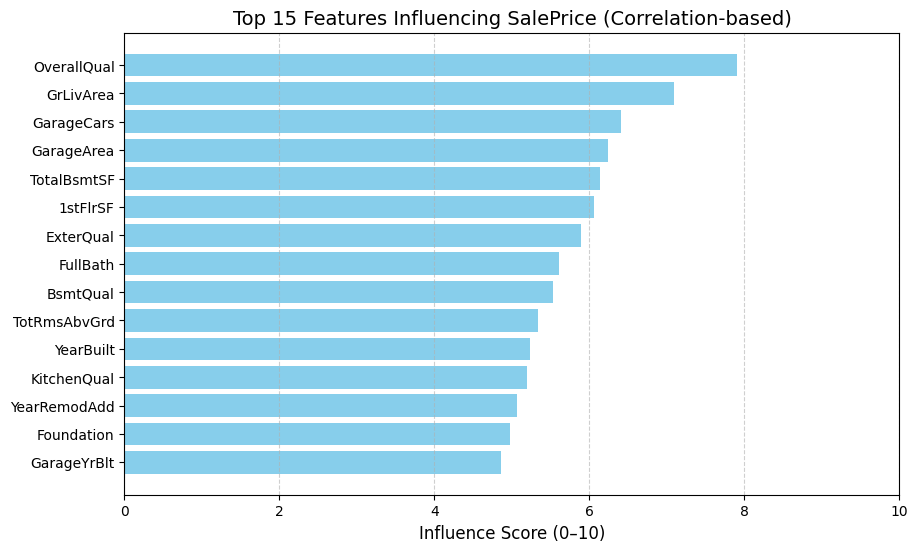

In [24]:
import matplotlib.pyplot as plt

# 取前15个最相关的变量
top_n = 15
top_features = result.head(top_n)

plt.figure(figsize=(10,6))
plt.barh(top_features.index[::-1], top_features['influence_score_0_to_10'][::-1], color='skyblue')
plt.xlabel("Influence Score (0–10)", fontsize=12)
plt.title(f"Top {top_n} Features Influencing SalePrice (Correlation-based)", fontsize=14)
plt.xlim(0, 10)   # 分数标准化到 0–10
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

In [ ]:
比较 生活面积 和 质量 对于 sale price 的影响


In [ ]:
太好了，就按 GrLivArea vs OverallQual 做“控制变量”的对比。我给你一段可直接跑的代码，包含三部分：

固定质量（OverallQual=7），看面积变化对价格的影响（斜率 & R² + 散点+拟合线）

固定面积区间（默认 1500–2000 sqft），看质量评分变化对价格的影响（斜率 & R² + 折线）

多元线性回归（同时放入 GrLivArea 和 OverallQual），量化“在控制另一个变量下”的边际影响（每 100 sqft 增加多少 $、质量每 +1 增加多少 $）

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========= 0) 读取数据（如果你已经有 df，就注释掉下面两行） =========
# df = pd.read_csv("train.csv")  # Kaggle House Prices
# df = df.dropna(subset=["SalePrice","GrLivArea","OverallQual"]).copy()

def fit_line_and_r2(x, y):
    """最小二乘拟合 y = m*x + b，并返回 m, b, R^2"""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m, b = np.polyfit(x, y, 1)
    # 用相关系数的平方近似 R^2（在简单线性回归情形等价）
    r = np.corrcoef(x, y)[0, 1]
    r2 = float(r**2) if not np.isnan(r) else np.nan
    return m, b, r2

# ========= 1) 控制质量：只看 OverallQual = q 的样本，比较 GrLivArea→SalePrice =========
def analyze_area_given_quality(df, q=7, min_samples=30):
    sub = df.loc[(df["OverallQual"] == q) & df["GrLivArea"].notna() & df["SalePrice"].notna(),
                 ["GrLivArea","SalePrice"]].copy()
    n = len(sub)
    if n < min_samples:
        print(f"[提示] OverallQual={q} 的样本量只有 {n}，可能不稳定（建议换个 q 或降低 min_samples）")

    m, b, r2 = fit_line_and_r2(sub["GrLivArea"], sub["SalePrice"])
    # 斜率解释：每 100 sqft 增加的价格
    per_100_sqft = m * 100.0

    # 画图（散点 + 拟合线）
    plt.figure(figsize=(9,6))
    plt.scatter(sub["GrLivArea"], sub["SalePrice"], s=14, alpha=0.6)
    x_line = np.linspace(sub["GrLivArea"].min(), sub["GrLivArea"].max(), 200)
    y_line = m * x_line + b
    plt.plot(x_line, y_line)
    plt.title(f"SalePrice vs GrLivArea  (OverallQual = {q})")
    plt.xlabel("GrLivArea (sq ft)")
    plt.ylabel("SalePrice")
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"[固定质量 OverallQual={q}]")
    print(f"样本量 n = {n}")
    print(f"拟合：SalePrice ≈ {m:.2f} * GrLivArea + {b:.2f}")
    print(f"R^2 = {r2:.3f}")
    print(f"边际影响 ≈ 每增加 100 sqft，价格 +${per_100_sqft:,.0f}")
    return {"n": n, "slope": m, "intercept": b, "R2": r2, "delta_$per100sqft": per_100_sqft}

# ========= 2) 控制面积：只看指定面积区间，比较 OverallQual→SalePrice =========
def analyze_quality_given_area(df, area_range=(1500, 2000), min_samples=30):
    lo, hi = area_range
    sub = df.loc[
        df["GrLivArea"].between(lo, hi, inclusive="both")
        & df["OverallQual"].notna() & df["SalePrice"].notna(),
        ["OverallQual","SalePrice"]
    ].copy()
    n = len(sub)
    if n < min_samples:
        print(f"[提示] 面积区间 {lo}-{hi} 的样本量只有 {n}，可能不稳定（可放宽区间）")

    # 按质量评分取中位数（更稳健）
    grouped = (sub.groupby("OverallQual")["SalePrice"]
                  .median().reset_index().sort_values("OverallQual"))
    # 线性拟合（质量评分→价格）
    m, b, r2 = fit_line_and_r2(grouped["OverallQual"], grouped["SalePrice"])

    # 画图（折线）
    plt.figure(figsize=(9,6))
    plt.plot(grouped["OverallQual"], grouped["SalePrice"], marker='o')
    plt.title(f"Median SalePrice by OverallQual  (GrLivArea in [{lo}, {hi}])")
    plt.xlabel("OverallQual")
    plt.ylabel("Median SalePrice")
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"[固定面积 {lo}-{hi} sqft]")
    print(f"样本量 n = {n}  （用于折线的点数 = {len(grouped)} 个质量等级）")
    print(f"拟合：Median(SalePrice) ≈ {m:.2f} * OverallQual + {b:.2f}")
    print(f"R^2 = {r2:.3f}")
    print(f"边际影响 ≈ 质量每 +1，价格 +${m:,.0f}（以中位数为代表）")
    return {"n": n, "slope_$per_qual": m, "intercept": b, "R2": r2}

# ========= 3) 多元线性回归：同时放入 GrLivArea 和 OverallQual =========
def multivariate_ols(df):
    from statsmodels.api import OLS, add_constant
    sub = df[["SalePrice","GrLivArea","OverallQual"]].dropna().copy()
    X = add_constant(sub[["GrLivArea","OverallQual"]])
    y = sub["SalePrice"].values
    model = OLS(y, X).fit()
    coef = model.params  # const, GrLivArea, OverallQual
    # 把 GrLivArea 的斜率转成“每 100 sqft 的边际影响”
    per_100_sqft = coef["GrLivArea"] * 100.0

    print("\n[多元线性回归：SalePrice ~ GrLivArea + OverallQual]")
    print(model.summary())

    print("\n[边际影响（控制另一变量后）]")
    print(f"• 每增加 100 sqft，价格 +${per_100_sqft:,.0f}（控制质量不变）")
    print(f"• 质量每 +1，价格 +${coef['OverallQual']:,.0f}（控制面积不变）")
    return {"coef": coef, "per100sqft_$": per_100_sqft, "summary": model}

# ======== 示例调用（按你的需求可直接运行） ========
# 1) 只看质量=7（你也可以换成 6 / 8）
# res1 = analyze_area_given_quality(df, q=7)

# 2) 只看面积 1500–2000 sqft（可改成 (1400, 2200) 等）
# res2 = analyze_quality_given_area(df, area_range=(1500, 2000))

# 3) 多元 OLS：同时量化两个变量的边际影响
# res3 = multivariate_ols(df)

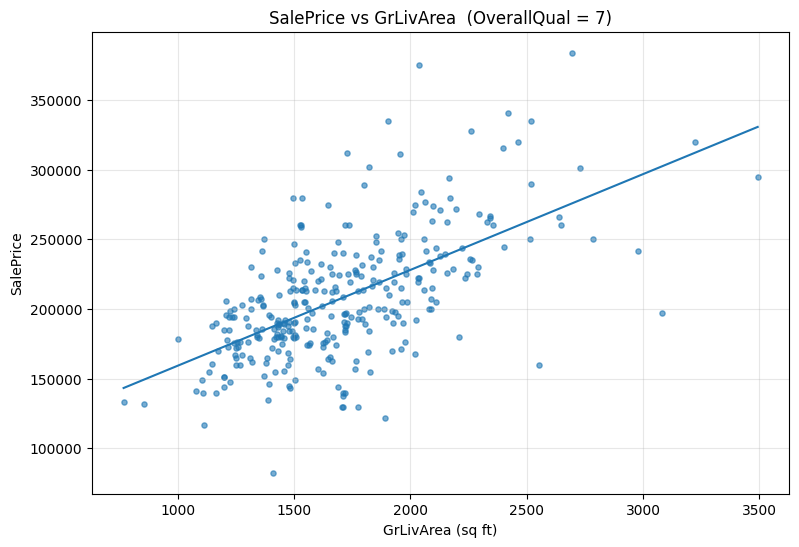

[固定质量 OverallQual=7]
样本量 n = 319
拟合：SalePrice ≈ 68.75 * GrLivArea + 90586.31
R^2 = 0.367
边际影响 ≈ 每增加 100 sqft，价格 +$6,875


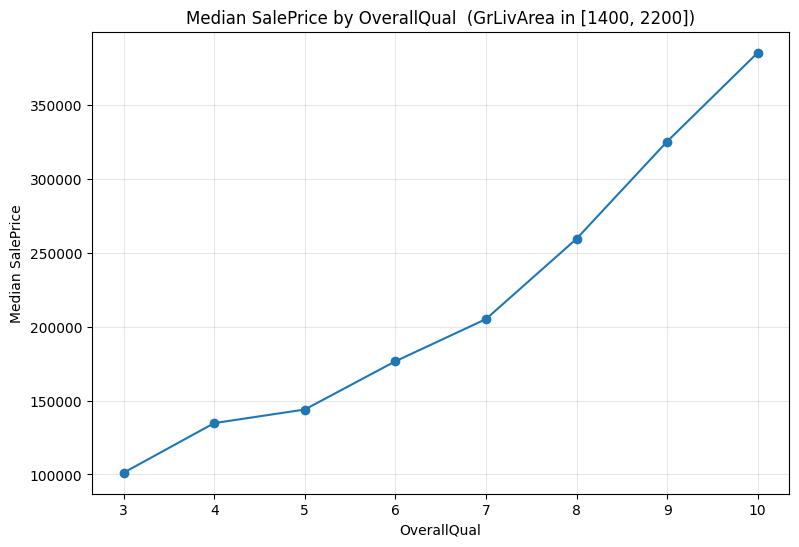

[固定面积 1400-2200 sqft]
样本量 n = 662  （用于折线的点数 = 8 个质量等级）
拟合：Median(SalePrice) ≈ 39435.36 * OverallQual + -40009.07
R^2 = 0.947
边际影响 ≈ 质量每 +1，价格 +$39,435（以中位数为代表）

[多元线性回归：SalePrice ~ GrLivArea + OverallQual]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.714
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     1820.
Date:                Mon, 22 Sep 2025   Prob (F-statistic):               0.00
Time:                        17:42:15   Log-Likelihood:                -17630.
No. Observations:                1460   AIC:                         3.527e+04
Df Residuals:                    1457   BIC:                         3.528e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
    

In [27]:
# ==== 固定质量等级 7：看面积对价格的影响 ====
res1 = analyze_area_given_quality(df, q=7)

# ==== 固定面积区间 1400–2200：看质量对价格的影响 ====
res2 = analyze_quality_given_area(df, area_range=(1400, 2200))

# ==== 多元线性回归：同时考虑 GrLivArea + OverallQual ====
res3 = multivariate_ols(df)

In [ ]:
1. 固定质量等级（OverallQual=7）时的面积影响

样本量：319

回归方程：

𝑆
𝑎
𝑙
𝑒
𝑃
𝑟
𝑖
𝑐
𝑒
≈
68.75
×
𝐺
𝑟
𝐿
𝑖
𝑣
𝐴
𝑟
𝑒
𝑎
+
90586
SalePrice≈68.75×GrLivArea+90586

R² = 0.367
说明在固定质量为7的条件下，面积可以解释约 36.7% 的价格差异。

边际效应：
每增加 100 sqft，价格平均 上涨 $6,875。

➡️ 直观意义：在质量一样的情况下，面积越大价格越高，但解释力（R²=0.367）中等，说明还有其他重要因素（比如质量本身、地段、年份）。

2. 固定面积（1400–2200 sqft）时的质量影响

样本量：662

回归方程：

Median(SalePrice)≈39435×OverallQual−40009

R² = 0.947
说明 质量等级几乎决定了大部分的价格差异（>94%）。

边际效应：
每提升 1 个质量等级，价格 上涨约 $39,435。

➡️ 直观意义：在面积差不多时，质量等级是决定价格的关键，解释力非常强。

3. 多元回归：面积 + 质量

R² = 0.714
两个变量一起能解释约 71.4% 的价格差异。

系数：

GrLivArea: 每增加 100 sqft，价格 ↑ $5,586（控制质量不变）。

OverallQual: 每提升 1 级，价格 ↑ $32,849（控制面积不变）。

➡️ 直观意义：质量等级的边际效应比面积大得多，说明 质量对房价的影响更显著。
但两者结合能更好地解释价格波动。

综合解读

单看面积：影响有限，R²不高（0.36）。

单看质量：非常强，几乎解释一切（R²≈0.95）。

两者结合：解释力提高到0.71，但质量依然是主导因素。

📌 结论：

质量等级（OverallQual）是决定房价的最核心变量。

面积（GrLivArea）是次要但依然重要的修正因素。

对买房者来说，房子大固然好，但质量差的房子即使很大，价格提升也有限。

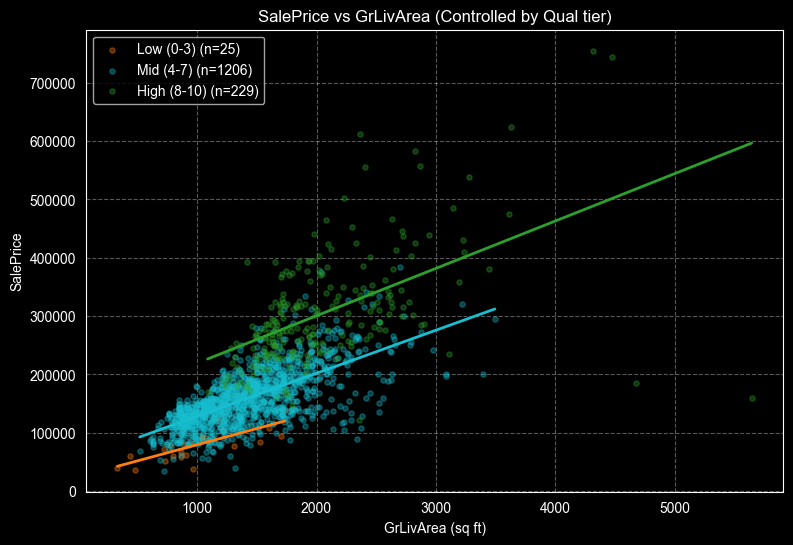

[Low (0-3) ] n=  25 | slope≈ $5,541 / +100 sqft | R^2=0.563
[Mid (4-7) ] n=1206 | slope≈ $7,384 / +100 sqft | R^2=0.448
[High (8-10)] n= 229 | slope≈ $8,127 / +100 sqft | R^2=0.276


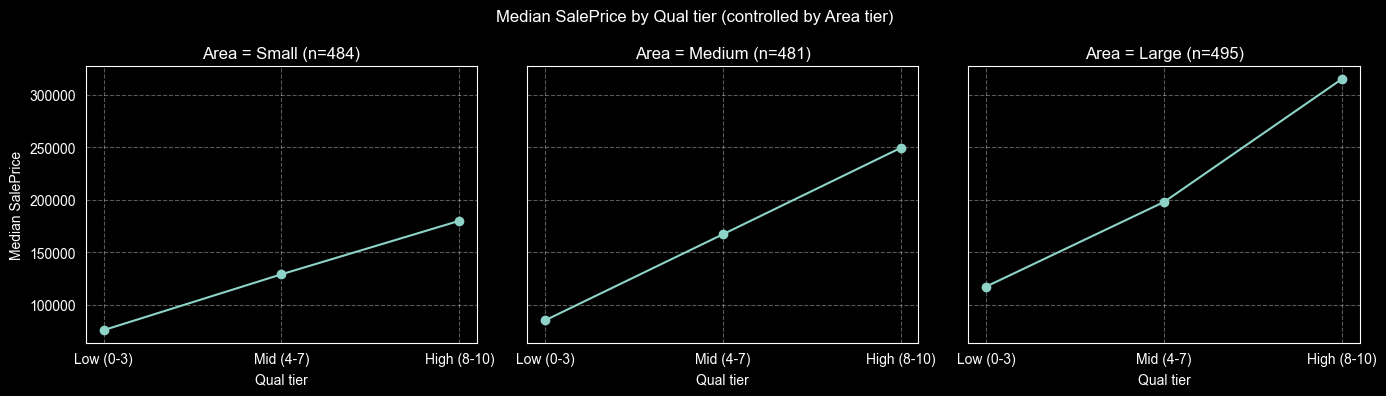

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ========== 0) 准备数据 ==========
# 目标列必须非空
df = df.dropna(subset=['SalePrice']).copy()

# 质量三类（0–3 低，4–7 中，8–10 高）
def qual_bucket(q):
    if q <= 3:
        return 'Low (0-3)'
    elif q <= 7:
        return 'Mid (4-7)'
    else:
        return 'High (8-10)'

df['QualTier'] = df['OverallQual'].apply(qual_bucket)

# 面积三档（按 33%、66% 分位自动切：小/中/大）
q33, q66 = np.percentile(df['GrLivArea'].dropna(), [33, 66])
def area_bucket(a):
    if a <= q33:
        return 'Small'
    elif a <= q66:
        return 'Medium'
    else:
        return 'Large'

df['AreaTier'] = df['GrLivArea'].apply(area_bucket)

# 用到的子集必须完整
df_sub = df[['SalePrice','GrLivArea','OverallQual','QualTier','AreaTier']].dropna().copy()

# 一个小工具：返回直线 y = m*x + b 的 m、b、R^2
def fit_line_and_r2(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m, b = np.polyfit(x, y, 1)
    r = np.corrcoef(x, y)[0,1]
    r2 = float(r*r) if np.isfinite(r) else np.nan
    return m, b, r2

# ========== 1) 固定质量档：看 "面积→价格" ==========
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(9,6))

stats_qual = []  # 收集斜率/R2/样本数

for tier, color in zip(['Low (0-3)','Mid (4-7)','High (8-10)'], ['tab:orange','tab:cyan','tab:green']):
    sub = df_sub[df_sub['QualTier']==tier]
    if len(sub) < 20:  # 样本太少就跳过
        continue
    # 散点
    ax.scatter(sub['GrLivArea'], sub['SalePrice'], s=14, alpha=0.35, label=f'{tier} (n={len(sub)})', color=color)
    # 拟合线
    m, b, r2 = fit_line_and_r2(sub['GrLivArea'], sub['SalePrice'])
    xline = np.linspace(sub['GrLivArea'].min(), sub['GrLivArea'].max(), 200)
    ax.plot(xline, m*xline + b, lw=2, color=color)
    stats_qual.append((tier, m, r2, len(sub)))

ax.set_title('SalePrice vs GrLivArea (Controlled by Qual tier)')
ax.set_xlabel('GrLivArea (sq ft)')
ax.set_ylabel('SalePrice')
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(loc='upper left')
plt.show()

# 打印每个质量档的斜率/R^2（把斜率换算成“每 +100 sqft 增加多少钱”）
for tier, m, r2, n in stats_qual:
    print(f"[{tier:10s}] n={n:4d} | slope≈ ${m*100:,.0f} / +100 sqft | R^2={r2:.3f}")

# ========== 2) 固定面积档：看 "质量→价格"（中位数折线：复刻你最后那张图的思路） ==========
fig, axes = plt.subplots(1, 3, figsize=(14,4), sharey=True)
area_order = ['Small','Medium','Large']
qual_order = ['Low (0-3)','Mid (4-7)','High (8-10)']

for i, area in enumerate(area_order):
    sub = df_sub[df_sub['AreaTier']==area]
    # 质量→中位价
    grouped = (sub.groupby('QualTier')['SalePrice']
               .median()
               .reindex(qual_order))
    axes[i].plot(qual_order, grouped.values, marker='o')
    axes[i].set_title(f'Area = {area} (n={len(sub)})')
    axes[i].set_xlabel('Qual tier')
    if i == 0:
        axes[i].set_ylabel('Median SalePrice')
    axes[i].grid(True, linestyle='--', alpha=0.35)

plt.suptitle('Median SalePrice by Qual tier (controlled by Area tier)')
plt.tight_layout()
plt.show()


===== Summary =====
               count        mean        std      min       5%        25%  \
SalePrice     1460.0  180921.196  79442.503  34900.0  88000.0  129975.00   
OverallQual   1460.0       6.099      1.383      1.0      4.0       5.00   
YearBuilt     1460.0    1971.268     30.203   1872.0   1916.0    1954.00   
YearRemodAdd  1460.0    1984.866     20.645   1950.0   1950.0    1967.00   
HouseAge      1460.0      36.548     30.250      0.0      1.0       8.00   
GrLivArea     1460.0    1515.464    525.480    334.0    848.0    1129.50   
TotalBsmtSF   1460.0    1057.429    438.705      0.0    519.3     795.75   
GarageCars    1460.0       1.767      0.747      0.0      0.0       1.00   
GarageArea    1460.0     472.980    213.805      0.0      0.0     334.50   
LotArea       1460.0   10516.828   9981.265   1300.0   3311.7    7553.50   
TotalBaths    1460.0       2.211      0.785      1.0      1.0       2.00   

                   50%        75%        95%       max    skew  mis

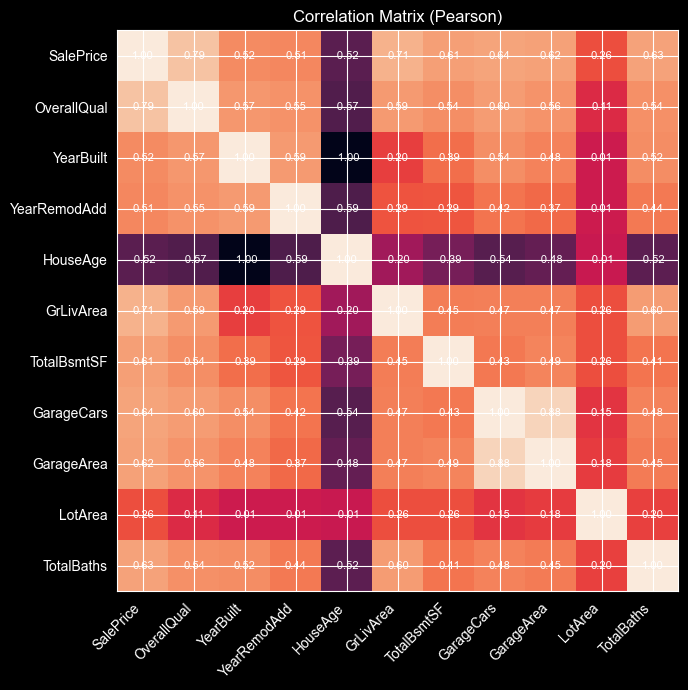


===== Correlation Matrix (Spearman) =====
              SalePrice  OverallQual  YearBuilt  YearRemodAdd  HouseAge  \
SalePrice         1.000        0.810      0.653         0.571    -0.650   
OverallQual       0.810        1.000      0.647         0.558    -0.644   
YearBuilt         0.653        0.647      1.000         0.684    -0.996   
YearRemodAdd      0.571        0.558      0.684         1.000    -0.677   
HouseAge         -0.650       -0.644     -0.996        -0.677     1.000   
GrLivArea         0.731        0.603      0.288         0.282    -0.289   
TotalBsmtSF       0.603        0.460      0.427         0.299    -0.423   
GarageCars        0.691        0.609      0.602         0.456    -0.600   
GarageArea        0.649        0.542      0.528         0.398    -0.525   
LotArea           0.456        0.233      0.103         0.075    -0.105   
TotalBaths        0.704        0.557      0.553         0.413    -0.551   

              GrLivArea  TotalBsmtSF  GarageCars  Garage

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== 1) 构造特征 =====
# 若 df 已存在可跳过下一行
# df = pd.read_csv("train.csv")

df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["TotalBaths"] = (
    df["FullBath"].fillna(0)
    + 0.5*df["HalfBath"].fillna(0)
    + df["BsmtFullBath"].fillna(0)
    + 0.5*df["BsmtHalfBath"].fillna(0)
)

cols = [
    "SalePrice","OverallQual","YearBuilt","YearRemodAdd","HouseAge",
    "GrLivArea","TotalBsmtSF","GarageCars","GarageArea","LotArea","TotalBaths"
]
X = df[cols].copy()

# ===== 2) 摘要统计（含偏度/缺失）=====
summary = X.describe(percentiles=[.05,.25,.5,.75,.95]).T
summary["skew"] = X.skew(numeric_only=True)
summary["missing"] = X.isna().sum()
print("===== Summary =====")
print(summary.round(3))

# ===== 3) Pearson 相关矩阵 =====
corr = X.corr(numeric_only=True, method="pearson")
print("\n===== Correlation Matrix (Pearson) =====")
print(corr.round(3))

# 与 SalePrice 的相关排序
corr_to_price = corr["SalePrice"].drop("SalePrice").sort_values(ascending=False)
print("\n===== Correlation with SalePrice (sorted) =====")
print(corr_to_price.round(3))

# ===== 4) 热力图（单图、matplotlib、不指定颜色）=====
fig, ax = plt.subplots(figsize=(9,7))
im = ax.imshow(corr.values, interpolation="nearest")  # 默认配色

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(corr.index)))
ax.set_yticklabels(corr.index)

# 在格子里标注数值
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Correlation Matrix (Pearson)")
fig.tight_layout()
plt.show()

# ===== 5) （可选）Spearman 相关（对非线性/排序更稳健）=====
corr_s = X.corr(numeric_only=True, method="spearman")
print("\n===== Correlation Matrix (Spearman) =====")
print(corr_s.round(3))

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate, KFold, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('dark_background')

# 1) 数据与特征
df = pd.read_csv("train.csv").dropna(subset=["SalePrice"]).copy()
df["HouseAge"]  = df["YrSold"] - df["YearBuilt"]
df["TotalBaths"] = (
    df["FullBath"].fillna(0)
    + 0.5*df["HalfBath"].fillna(0)
    + df["BsmtFullBath"].fillna(0)
    + 0.5*df["BsmtHalfBath"].fillna(0)
)

FEATURES = [
    "OverallQual","GrLivArea","TotalBsmtSF",
    "GarageCars","GarageArea","LotArea",
    "YearBuilt","YearRemodAdd","HouseAge","TotalBaths"
]
X = df[FEATURES].copy()
y = df["SalePrice"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2) 基线模型（带中位数填补 + 目标log变换）
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=42,
)
rf_pipe = make_pipeline(SimpleImputer(strategy="median"), rf)

model = TransformedTargetRegressor(
    regressor=rf_pipe,
    func=np.log1p,
    inverse_func=np.expm1
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_res = cross_validate(
    model, X_train, y_train, cv=cv,
    scoring={
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    n_jobs=-1
)
print("=== Baseline CV (5-fold) ===")
print(f"RMSE: {-cv_res['test_rmse'].mean():,.0f} ± {-cv_res['test_rmse'].std():,.0f}")
print(f"MAE : {-cv_res['test_mae'].mean():,.0f} ± {-cv_res['test_mae'].std():,.0f}")
print(f"R^2 :  {cv_res['test_r2'].mean():.3f}")

# 3) 轻量随机搜索
param_distributions = {
    "regressor__randomforestregressor__n_estimators": np.arange(300, 1101, 100),
    "regressor__randomforestregressor__max_depth": [None] + list(np.arange(6, 25, 2)),
    "regressor__randomforestregressor__min_samples_split": np.arange(2, 11),
    "regressor__randomforestregressor__min_samples_leaf":  np.arange(1, 6),
    "regressor__randomforestregressor__max_features": ["auto", "sqrt", 0.5, 0.7, 1.0],
}
search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=25,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search.fit(X_train, y_train)

print("\n=== Best Params ===")
print(search.best_params_)
print(f"CV Best RMSE: {-search.best_score_:,.0f}")

best_model = search.best_estimator_
best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

rmse = mean_squared_error(y_test, pred, squared=False)
mae  = mean_absolute_error(y_test, pred)
r2   = r2_score(y_test, pred)
print("\n=== Test Metrics ===")
print(f"RMSE: {rmse:,.0f}")
print(f"MAE : {mae:,.0f}")
print(f"R^2 : {r2:.3f}")

# 4) 特征重要性
rf_final = best_model.regressor_.named_steps["randomforestregressor"]
imp = pd.Series(rf_final.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(8,6))
imp.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

=== Baseline CV (5-fold) ===
RMSE: 32,426 ± -4,567
MAE : 19,426 ± -726
R^2 :  0.820
Fitting 5 folds for each of 25 candidates, totalling 125 fits


C:\Users\User\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
30 fits failed out of a total of 125.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
23 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\User\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\User\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\com


=== Best Params ===
{'regressor__randomforestregressor__n_estimators': np.int64(500), 'regressor__randomforestregressor__min_samples_split': np.int64(5), 'regressor__randomforestregressor__min_samples_leaf': np.int64(2), 'regressor__randomforestregressor__max_features': 0.7, 'regressor__randomforestregressor__max_depth': np.int64(24)}
CV Best RMSE: 31,904


TypeError: got an unexpected keyword argument 'squared'

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
X = np.array([[1, 1], [1, 2], [2, 2], [2, 3]])
# y = 1 * x_0 + 2 * x_1 + 3
y = np.dot(X, np.array([1, 2])) + 3
reg = LinearRegression().fit(X, y)
reg.score(X, y)
1.0
reg.coef_
array([1., 2.])
reg.intercept_
np.float64(3.0)
reg.predict(np.array([[3, 5]]))
array([16.])

In [23]:
import numpy as np
from sklearn.linear_model import LinearRegression

cols = [
    "OverallQual","YearBuilt","YearRemodAdd","HouseAge",
    "GrLivArea","TotalBsmtSF","GarageCars","GarageArea","LotArea","TotalBaths"
]
X=df[cols]
Y=df["SalePrice"]
reg = LinearRegression().fit(X, Y)
print(reg.score(X, Y))
print(reg.coef_)
print(reg.intercept_)

0.7804268147503655
[ 2.00675730e+04 -1.25553702e+02  2.64798480e+02 -2.80799513e+02
  4.13765635e+01  2.60166824e+01  8.96292777e+03  1.88190432e+01
  6.13431403e-01  8.03738359e+03]
-348478.11532166204


In [27]:
df['model_predicted_prcie']=reg.predict(X)
df['error_rate']=abs(df['SalePrice']-df['model_predicted_prcie'])
print(df['model_predicted_prcie'].mean()-df['SalePrice'].mean())

-5.820766091346741e-11


In [30]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
cols = [
    "OverallQual","YearBuilt","YearRemodAdd","HouseAge",
    "GrLivArea","TotalBsmtSF","GarageCars","GarageArea","LotArea","TotalBaths"
]
X=df[cols]
Y=df["SalePrice"]
regr = RandomForestRegressor(n_estimators=1000,max_depth=3, random_state=0)
regr.fit(X, Y)
print(regr.score(X, Y))
df['model_predicted_prcie']=regr.predict(X)
df['error_rate']=abs(df['SalePrice']-df['model_predicted_prcie'])
print(df['model_predicted_prcie'].mean()-df['SalePrice'].mean())

0.7945834655136788
-68.94486614625202


In [31]:
regr.feature_importances_

array([0.78279397, 0.00305798, 0.00842618, 0.00113119, 0.11625413,
       0.0369153 , 0.02010546, 0.00590888, 0.00451619, 0.02089072])